<a href="https://colab.research.google.com/github/ColeDeBois/Altmanlab/blob/main/DeBois_Analysis_250212_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount the Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# The code below sets the initial conditions and creates functions that are used later

In [ ]:
# import libraries
from __future__ import division
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import curve_fit
from scipy import signal
import warnings
#warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)
from tkinter import filedialog
from scipy.signal import welch #, hamming
from scipy.fft import fft, fftfreq
import glob
import tkinter

# define constants
fs = 50000  # data collection rate
dt = 1/fs
kBT = 4.11e-21     # room temp (J)
#eta = 0.001  # Pa s, viscosity of water
#eta = 0.002548 # Pa s, viscosity of BSA solution
eta = 0.001856 # Pa s

r = (2.0e-6)/2      # radius of bead
D = kBT /(6*np.pi*eta*r)    # diffusion constant
beta = 6*np.pi*eta*r

In [ ]:
# Create functions

def calcpowerspec2(data):    # Calculate power spectrum
    f, Pxx_den = signal.welch(data, fs,  nperseg=int(len(data)), window='hamming')
    return f, Pxx_den

def openfile(filename):   # open files
    fid = open(filename, 'rb')
    dim = np.fromfile(fid, dtype='>d')
    fid.close()
    return dim

def autocorrFFT(x):     # used by the program that calculates the meansquared displacement
    N=len(x)
    F = np.fft.fft(x, n=2*N)  #2*N because of zero-padding
    PSD = F * F.conjugate()
    res = np.fft.ifft(PSD)
    res= (res[:N]).real   #now we have the autocorrelation in convention B
    n=N*np.ones(N)-np.arange(0,N) #divide res(m) by (N-m)
    return res/n #this is the autocorrelation in convention A

def msd_fft(x, y):      # calculate the mean squared displacement
    # Organize the data into a 2-column array where each row contains an x and y position
    r = np.ones((int(len(x)), 2))
    for i in range(0,int(len(x))):
        values = [x[i], y[i]]
        r[i] =  values

    # calculate the MSD using the FFT
    N=len(r)
    D=np.square(r).sum(axis=1)
    D=np.append(D,0)
    S2=sum([autocorrFFT(r[:, i]) for i in range(r.shape[1])])
    Q=2*D.sum()
    S1=np.zeros(N)
    for m in range(N):
        Q=Q-D[m-1]-D[N-m]
        S1[m]=Q/(N-m)
    msdval = S1-2*S2
    tau = np.multiply(dt, [i for i in range(0, len(msdval))])
    msdvalues = pd.DataFrame({'tau': tau, 'msd': msdval})
    return msdvalues

def func(x, a, b):    # fitting function for the PSD
    return a**2*(D/((np.pi)**2)) / ( (b/(2*np.pi*beta))**2 + x**2) # from eqn 10 Berg-Sorensen et al. 2004
       # a - Sensitivity - units of V/m
       # b - Stiffness - N/m

def loaddata(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    #longdatax = (longdatax)/(Sx/1e9)-trapx
    #longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatax = (longdatax)/(Sx)-trapx    # all in meters
    longdatay = (longdatay)/(Sy)-trapy    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg

# LOW PASS FILTER
def loaddatafilter(basename, firstnumber, lastnumber, PSflag, frequency):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(5001)
  powerspecy = np.zeros(5001)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 5
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    #longdatax = (longdatax)/(Sx/1e9)-trapx
    #longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatax = (longdatax)/(Sx)-trapx    # all in meters
    longdatay = (longdatay)/(Sy)-trapy    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')


  sos = signal.butter(10, frequency, 'hp', fs=50000, output='sos')
  longdatax = signal.sosfilt(sos, longdatax)
  longdatay = signal.sosfilt(sos, longdatay)

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg


def loaddataquiet(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:
        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    longdatax = (longdatax)/(Sx)-trapx    # all in meters
    longdatay = (longdatay)/(Sy)-trapy    # all in meters

  else:
    pass

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg



def calibrate(xb, yb, sumsignalb, f, powerspecx, powerspecy):
  # Calibrate the trap/detector

  initial = 5  # starting frequency for the fit
  list = [i for i in range(len(f)) if f[i] > 2000]     # final frequency
  final = list[0]

  t = dt*np.arange(0, len(xb))
  plt.figure(100)
  plt.loglog(f, powerspecx, 'k.')
  plt.xlabel('frequency [Hz]')
  plt.ylabel('PSD$_x$ [V$^2$/Hz]')
  plt.figure(101)
  plt.loglog(f, powerspecy, 'k.', label = 'Experimental Power Spectrum' )
  plt.axis('tight')
  plt.xlabel('frequency [Hz]')
  plt.ylabel('PSD$_y$ [V$^2$/Hz]')
  plt.legend()

  # Fit the power spectral density - x
  poptx, pcov = curve_fit(func, f[initial:final], powerspecx[initial:final], [100000, 0.001])
  alphax = np.abs(poptx[1])
  print('spring constant x (PS): ' + str(alphax*1e3), ' pN/nm')
  print('spring constant x (var): ' + str(kBT / np.var(xb[0:int(fs/50)]/poptx[0])*1e3), ' pN/nm')
  print('Sensitivity : ' + str(poptx[0]/1e6) + ' V/um')
  plt.figure(100)
  plt.plot(f[initial:final], func(f[initial:final], *poptx), 'r-')
  print('****************')
  # Fit the power spectral density - y
  popty, pcov = curve_fit(func, f[initial:final], powerspecy[initial:final], [100000, 0.001])
  alphay = np.abs(popty[1])
  print('spring constant y (PS): ' + str(alphay*1e3), ' pN/nm')
  print('spring constant y (var): ' + str(kBT / np.var(yb[0:int(fs/50)]/popty[0])*1e3), ' pN/nm')
  print('Sensitivity y: ' + str(popty[0]/1e6) + ' V/um')
  plt.figure(101)
  plt.plot(f[initial:final], func(f[initial:final], *popty), 'r-',
         label = 'Theoretical Power Spectrum')
  plt.legend()

  global kx
  global ky
  kx = alphax
  ky = alphay

  global Sx
  global Sy
  Sx = np.abs(poptx[0])  # units of V/m -- divide voltages by this to convert to distances
  Sy = np.abs(popty[0])  # units of V/m -- divide voltages by this to convert to distances

  plt.figure()
  plt.subplot(3, 1, 1)
  plt.plot(t, (xb)/(Sx/1e9) , 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('x [nm]')
  plt.subplot(3, 1, 2)
  plt.plot(t, (yb)/(Sy/1e9) , 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('y [nm]')
  plt.subplot(3, 1, 3)
  plt.plot(t, sumsignalb, 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('sum signal [V]')

  xb = (xb)/(Sx)  # units of m
  yb = (yb)/(Sy)  # units of m

  global trapx
  global trapy
  trapx = np.mean(xb) # Center of optical trap - x (m)
  trapy = np.mean(yb) # Center of optical trap - y (m)

def calcmsd(xb, yb):    # This calculates the MSD using the brute force approach
  # Calculate the MSD
  analysislength = 30   # the length of data that will be analyzed
  msdlength = 10      # the maximum value of tau plotted for the MSD plot

  # Select Brownian data to analyze MSD and Fourier transform
  xbrown = xb[0:int(analysislength/dt)]
  ybrown = yb[0:int(analysislength/dt)]

  msdvaluesbrown = msd_fft(xbrown, ybrown)
  plt.figure()
  plt.loglog(msdvaluesbrown.tau[1:int(msdlength/(dt))], msdvaluesbrown.msd[1:int(msdlength/(dt))], 'b.', label = 'Bead in the Optical Trap')
  plt.figure()
  msddatabrown = np.array(msdvaluesbrown.msd[1:int(msdlength/dt)]) / (1e18)
  N = len(msddatabrown)
  T = 1/fs
  yfbrown = fft(xbrown)
  xfbrown = fftfreq(N, T)[:N//2]
  plt.plot(xfbrown[1000:3000], 2.0/N * np.abs(yfbrown[1000:3000]))
  plt.xlabel('frequency (Hz)')
  plt.title('Fourier transform of MSD')
  plt.show()
  return msdvaluesbrown

# STEP 1: Analyze the Brownian motion data to calibrate the trap and detector

spring constant x (PS): 0.021994030666490468  pN/nm
spring constant x (var): 0.029693272488817066  pN/nm
Sensitivity : 1.0660121147797599 V/um
****************
spring constant y (PS): 0.01964541276145166  pN/nm
spring constant y (var): 0.0420242317636452  pN/nm
Sensitivity y: 0.7555024631909351 V/um


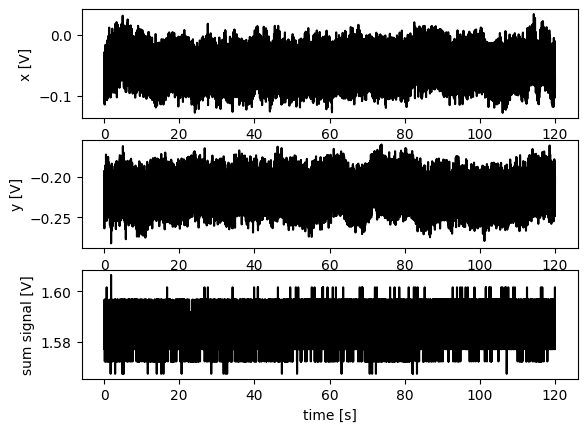

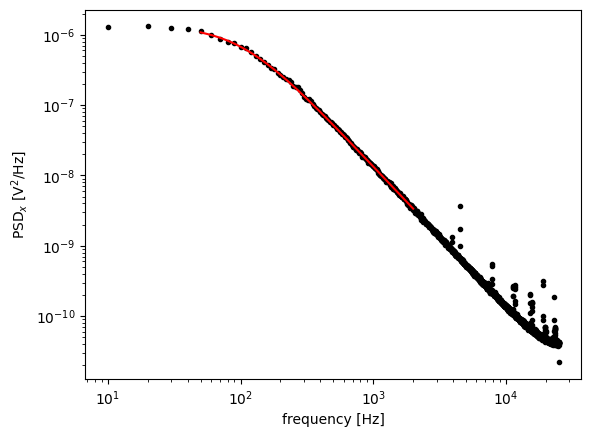

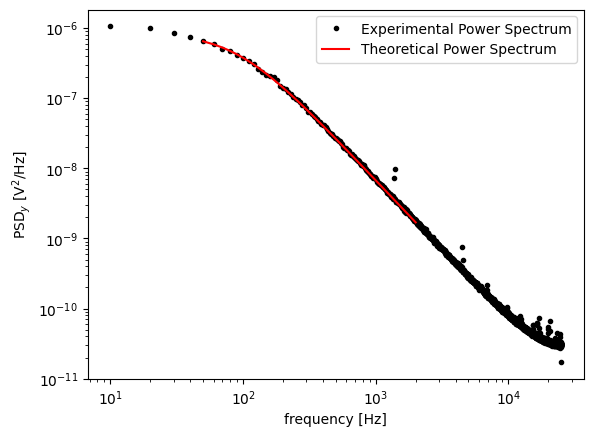

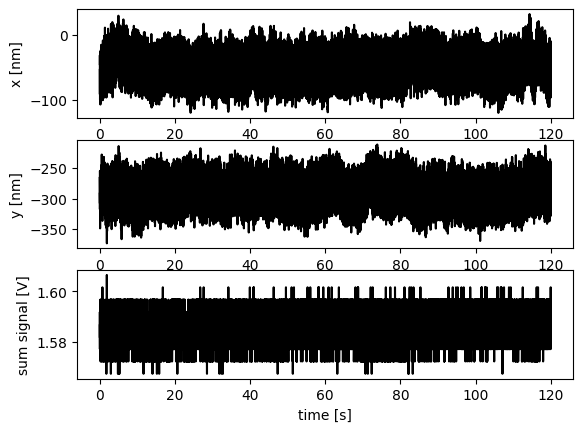

In [ ]:
pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'

if 'Sx' in globals():
  del Sx
  del Sy
  del trapx
  del trapy
  del kx
  del ky


xb, yb, sumsignalb, fg, f2, powerspecx2, powerspecy2 = loaddata('Brownian2/Brownian2_', 0, 120, 1)
calibrate(xb, yb, sumsignalb, f2, powerspecx2, powerspecy2)


# STEP 2: Function generator calibration

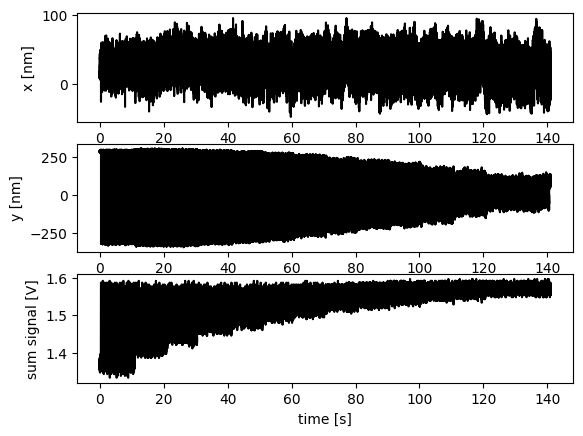

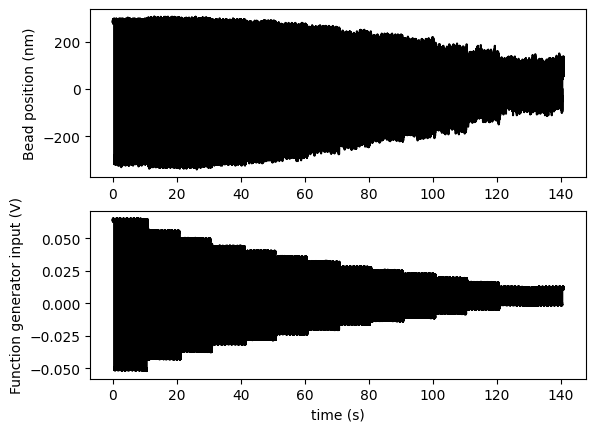

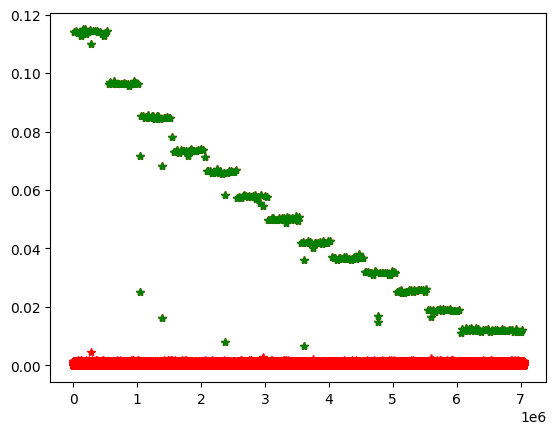

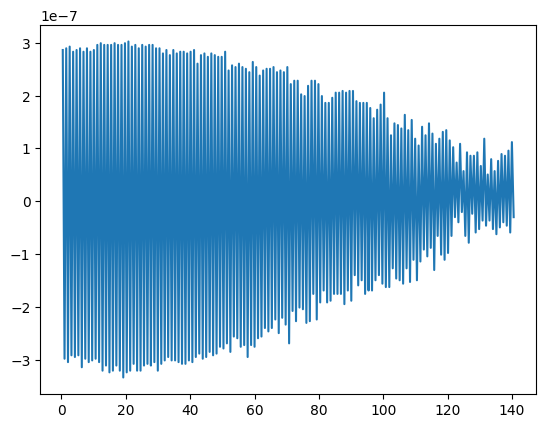

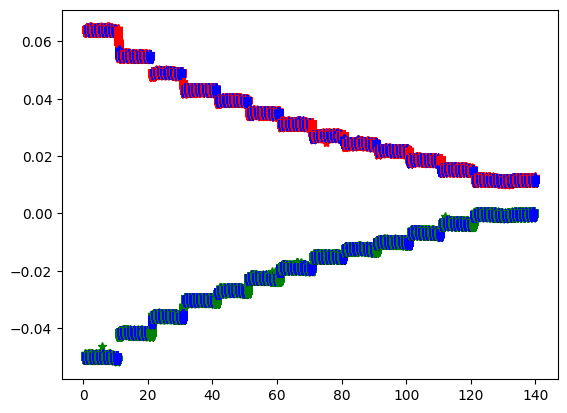

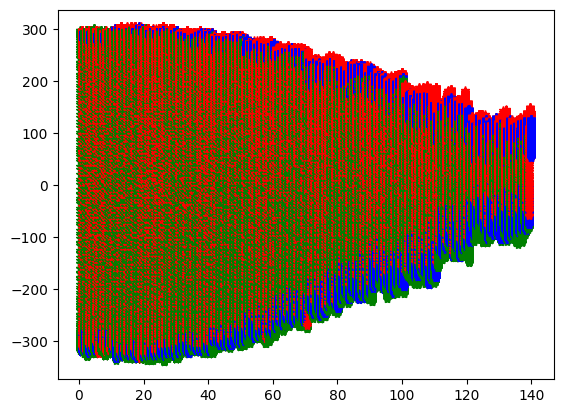

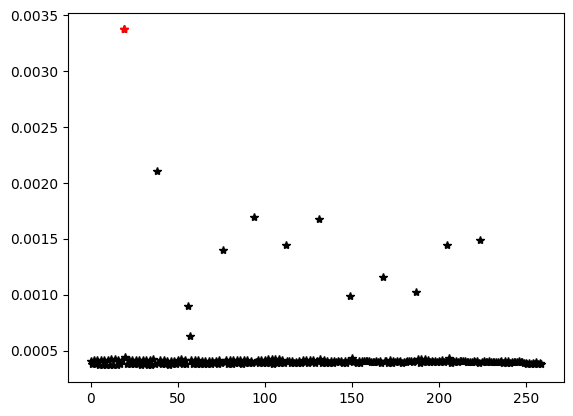

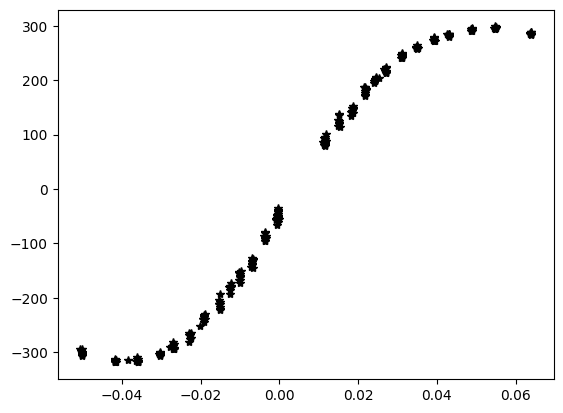

In [ ]:
pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'
# Load in the data
x, y, sumsignalb, fg = loaddata('FunctionG/FunctionG_', 0, 141, 0)
times = np.arange(0, len(fg)*dt, dt)

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(times, y*1e9, 'k')
plt.ylabel('Bead position (nm)')
plt.subplot(2, 1, 2)
plt.plot(times, fg, 'k')
plt.ylabel('Function generator input (V)')
plt.xlabel('time (s)')

# look for the transition points, where the function generator signla jumps
absdiff = np.append(np.abs(np.diff(fg)), 0)
#plt.figure()
#plt.plot(times, absdiff, 'k')
index = absdiff>(np.mean(absdiff)*20)
indexvalues = np.arange(0, len(index), 1)

plt.figure()
plt.plot(range(0, len(absdiff)), absdiff, 'r*')
plt.plot(np.array(range(0, len(absdiff)))[index], absdiff[index], 'g*')
plt.show()
plt.figure()
plt.plot(times[index], y[index])
plt.show()

# reduce the transtion points with multiple consecutive points to a single point
indexvaluesmarked = indexvalues[index]
indexvalueskeep = np.array([])
oldindex = indexvaluesmarked[0]
for i in range(1, len(indexvaluesmarked)):
  if indexvaluesmarked[i] == oldindex + 1:
    oldindex = indexvaluesmarked[i]
  else:
    indexvalueskeep = np.append(indexvalueskeep, oldindex)
    oldindex = indexvaluesmarked[i]

# Plot of the oscillating function generator signal, blue is where the calibration will be calculated
# calculation is done between (0.85 and 0.95 of the period) following the transition
plt.figure()
stdfg = np.array([])
for i in range(len(indexvalueskeep)-1):
   rangeval = (times > (times[int(indexvalueskeep[i])])) * (times < (times[int(indexvalueskeep[i+1])]))
   if int(i/2) == int(i)/2:
     plt.plot(times[rangeval], fg[rangeval] , 'g*')
     stdfg = np.append(stdfg, np.std(fg[rangeval]))
   else:
     plt.plot(times[rangeval], fg[rangeval] , 'r*')
     stdfg = np.append(stdfg, np.std(fg[rangeval]))

   rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.85)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
   plt.plot(times[rangeval],fg[rangeval], 'b*')
plt.show()


# Plot of the oscillating y signal, blue is where the calibration will be calculated
plt.figure()
for i in range(len(indexvalueskeep)-1):
   rangeval = (times > (times[int(indexvalueskeep[i])])) * (times < (times[int(indexvalueskeep[i+1])]))
   if int(i/2) == int(i)/2:
     plt.plot(times[rangeval], 1e9*y[rangeval] , 'g*')
   else:
     plt.plot(times[rangeval], 1e9*y[rangeval] , 'r*')

   rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.85)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
   plt.plot(times[rangeval],1e9*y[rangeval], 'b*')

# Plot to help us see what data are being thrown away because the amplitude at the fg is being varied
oscilnumber = np.arange(0, len(stdfg), 1)
plt.figure()
plt.plot(oscilnumber, stdfg, 'k*')
plt.plot(oscilnumber[stdfg>5*np.mean(stdfg)], stdfg[stdfg>5*np.mean(stdfg)], 'r*')

# This is our final calibration plot
plt.figure()
meanfgvals = np.array([])
meanyvals = np.array([])
for i in range(len(indexvalueskeep)-1):
  if stdfg[i]<5*np.mean(stdfg):
    rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.75)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
    meanfg = np.mean(fg[rangeval])
    meany = np.mean(y[rangeval])
    plt.plot(meanfg, meany*1e9, 'k*')

    meanfgvals = np.append(meanfgvals, meanfg)
    meanyvals = np.append(meanyvals, meany)

  else:
    #print('skip oscillation: ', i) # these are where we were changing the amplitude in the middle of the oscillation
    pass


### Take the function generator data, and fit it to get the calibration

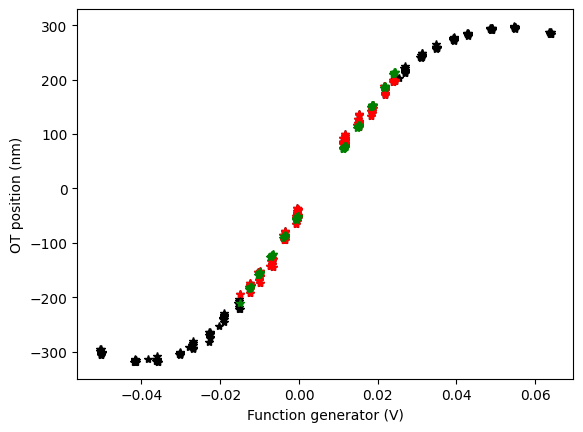

In [ ]:
plt.figure()
meanfgvals = np.array([])
meanyvals = np.array([])
for i in range(len(indexvalueskeep)-1):
  if stdfg[i]<5*np.mean(stdfg):
    rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.75)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
    meanfg = np.mean(fg[rangeval])
    meany = np.mean(y[rangeval])
    plt.plot(meanfg, meany*1e9, 'k*')

    meanfgvals = np.append(meanfgvals, meanfg)
    meanyvals = np.append(meanyvals, meany)

  else:
    #print('skip oscillation: ', i) # these are where we were changing the amplitude in the middle of the oscillation
    pass

# if we only trust the detector to a few 100 nm's away from the center, we should fit from about -400 <--> 400 along the y-detection
index = (meanyvals < 200*1e-9)*(meanyvals > -200*1e-9)
plt.plot(meanfgvals[index], 1e9*meanyvals[index], 'r*')

# Fitting a line
a, b = np.polyfit(meanfgvals[index], 1e9*meanyvals[index], 1)
plt.plot(meanfgvals[index], a * meanfgvals[index] + b, 'g*')
plt.ylabel('OT position (nm)')
plt.xlabel('Function generator (V)')

def OTposconversion(fgvals, a, b):
  return a * fgvals + b


# Passive Microrheology Analysis
## Each separate bead has its own cell

Bead 3: 3p-nt

499999
999998


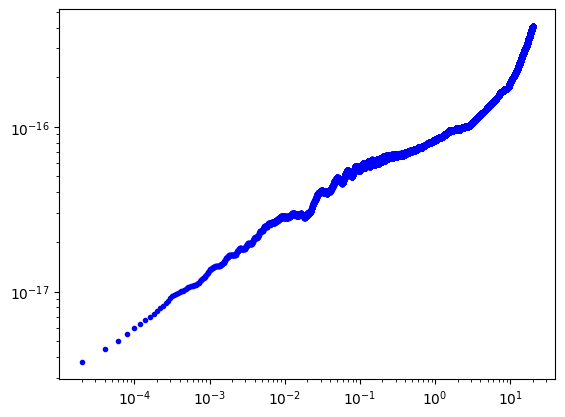

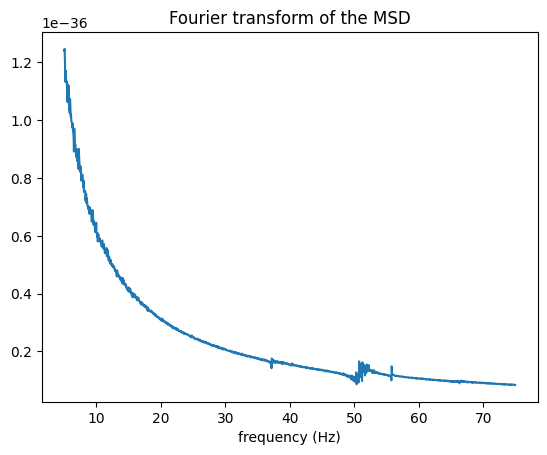

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


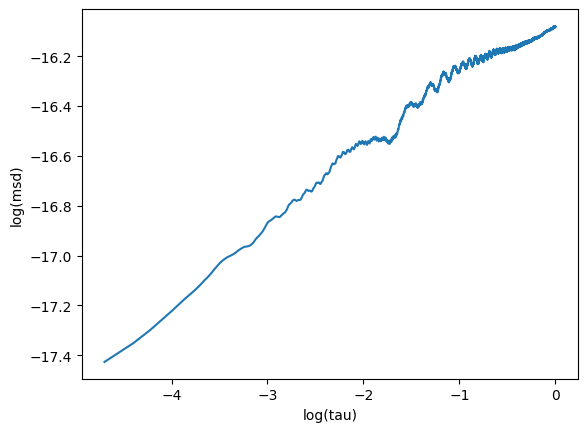

<ipython-input-7-99f067cd8cd6>:86: RuntimeWarning: invalid value encountered in scalar divide
  slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])


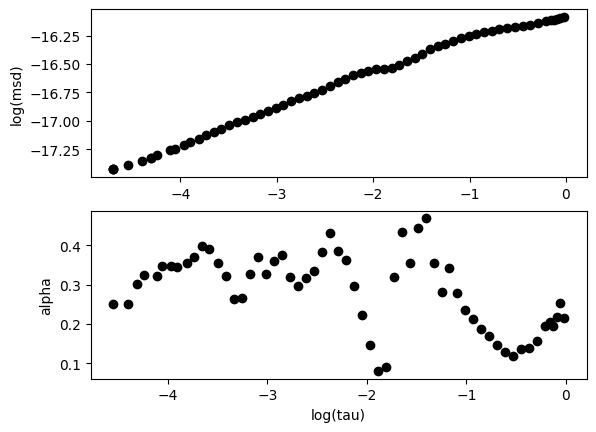

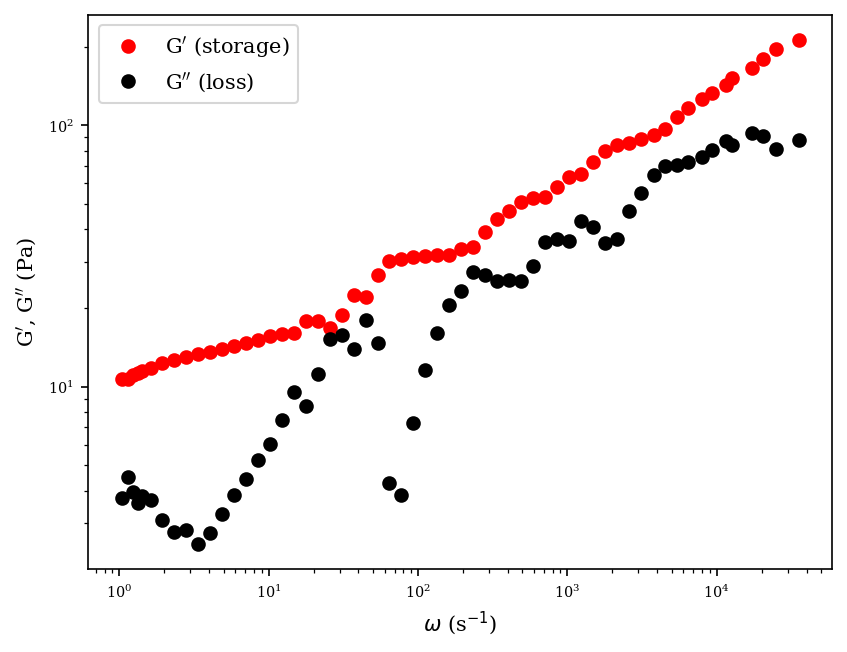

In [ ]:
from scipy import signal

pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'

def calcmsd2(x, y, analysislength, msdlength):

    dt = 1/50000
    fs = 50000
  # Select data to analyze MSD and fourier transform
    xdata = x[0:int(analysislength/dt)]
    ydata = y[0:int(analysislength/dt)]

    msdvalues = msd_fft(xdata, ydata)
    tautemp = msdvalues.tau
    msdtemp = msdvalues.msd
    msdvalues.tau = tautemp[0:int(msdlength/dt)]
    msdvalues.msd = msdtemp[0:int(msdlength/dt)]

    plt.figure()
    plt.loglog(msdvalues.tau[1:int(msdlength/(dt))], msdvalues.msd[1:int(msdlength/(dt))], 'b.')
    plt.figure()
    msddata = np.array(msdvalues.msd[1:int(msdlength/dt)]) / (1e18)
    N = len(msddata)
    T = 1/fs
    yf = fft(msddata)
    xf = fftfreq(N, T)[:N//2]

    print(len(xf))
    print(len(yf))
    plt.plot(xf[100:1500], 2.0/N * np.abs(yf[100:1500]))
    plt.xlabel('frequency (Hz)')
    plt.title('Fourier transform of the MSD')
    plt.show()
    return msdvalues

msdave = np.zeros(int(0.1*fs))
x, y, sumsignal, fg= loaddataquiet('bead3p-nt/bead3p-nt_', 0, 120, 0) # output is in m

msdvalues = calcmsd2(x, y, 120, 20) # Analyze the first 120 s, calculating the MSD for a maximum tau of 20 s
msdvaluesdata1 =  msdvalues
# initialize a list
alpha_list = []
omega_list = []
logtau_list = []
logmsd_list = []
tau_list = []
msd_list = []
analysislength = 1

def linear_alpha(x,m,b):
    return m*x+b

N = 0.4 #iteration step

logmsd = np.log10(msdvaluesdata1.msd[:int(analysislength*fs)])
logtau = np.log10(msdvaluesdata1.tau[:int(analysislength*fs)])
msd = (msdvaluesdata1.msd[:int(analysislength*fs)])
tau = (msdvaluesdata1.tau[:int(analysislength*fs)])

plt.figure()
plt.plot(logtau, logmsd)
plt.xlabel('log(tau)')
plt.ylabel('log(msd)')
plt.show()

for i in np.arange(-5, np.log10(5)-N, N/5):

    index = (logtau > i) * (logtau <i+N)
    logmsdsel = (logmsd[index])
    logtausel = (logtau[index])

    msdsel = msd[index]
    tausel = tau[index]

    n = len(tausel)

    logmsd_list.append(np.mean(logmsdsel))
    logtau_list.append(np.mean(logtausel))
    msd_list.append(np.mean(msdsel))
    tau_list.append(np.mean(tausel))

    omega_list.append(1/(10**(logtau_list[-1])))

    # METHOD 2 for calculating the slope
    if len(logmsd_list)>1:
        slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])
    else:
        slope = float("NaN")

    alpha_list.append(slope)

# DAVID: This plot shows us ln(msd) vs ln(tau) on the top.  The alpha curve on the bottom should be the slope of this curve
#   You may notice that the slope looks like it was calculated really well for the first part of the curve, but as we
#   move to the right, and the slope approaches zero, our calculation of the slope is  noisy
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(logtau_list, logmsd_list, 'ko')
plt.ylabel('log(msd)')

plt.subplot(2, 1, 2)
plt.plot(logtau_list, alpha_list, 'ko')
plt.ylabel('alpha')
plt.xlabel('log(tau)')
plt.show()

logtau_list_data = logtau_list
logmsd_list_data = logmsd_list

#CONSTANTS
d = 2 # number of dimensions (x and y)
T = 293.15 # room temp --> 20 celcius = 293.15 Kelvin
K_B = 1.3806e-23 # Boltzmann Constant J/K
radius = (2.0e-6)/2  # radius of the bead, we used 2.01 um diameter beads, multiplied by 10^-6 to get in meters (m)
kBT = 4.11e-21 # room temp * Boltzmann Const.

#lists
Greals2 = [] #list for all G'
Gimags2 = [] #List for all G''
Gstar_primes2 = []
Gstar_Dprimes2 = []
Gstars2 = []
#omegafinal2 = [];
for i in range (1, len(alpha_list)):
    #ω = 1 / tau[i]
    #msd = msd[i]
    #αω = αω[i-1]
    gamma = (0.457*(1+alpha_list[i])**2) - (1.36*(1+alpha_list[i])) + 1.9 #approx value from Mason 2000 p.373 below eqn. 8
    Gstar2 = abs((2*d*K_B*T) / (6*np.pi*radius*msd_list[i]*gamma))
    Gstars2.append(Gstar2)
    Gstar_prime2 = Gstar2 * np.cos((np.pi*alpha_list[i])/2)
    Gstar_Dprime2 = Gstar2 * np.sin((np.pi*alpha_list[i])/2)
    Gstar_primes2.append(Gstar_prime2)
    Gstar_Dprimes2.append(Gstar_Dprime2)

    ktrap = (kx+ky)/2
    offset =  ktrap/(6*np.pi*(1e-6))

    # DAVID: you need to subtract k / (6*pi*a) (kept in SI units)
    Greal2 = Gstar_prime2 #- offset # G' is subtracted by stiffness of the trap because it is the real component
    Gimag2 = Gstar_Dprime2
    Greals2.append(Greal2)
    Gimags2.append(Gimag2)
    #omegafinal2.append(1/msdvaluesdata1.tau[i])

plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')
plt.rcParams['figure.dpi']= 150

Greals2 = np.array(Greals2)
Gimags2 = np.array(Gimags2)

plt.figure()
plt.loglog(omega_list[1:], Greals2, 'ro', label='G$^\prime$ (storage)')
plt.loglog(omega_list[1:], Gimags2, 'ko', label='G$^{\prime\prime}$ (loss)')

plt.xlabel(r'$\omega$ (s$^{-1}$)')
plt.ylabel(r'G$^\prime$, G$^{\prime\prime}$ (Pa)')
plt.legend()
plt.show()

Gprime_3p = Greals2
Gprimeprime_3p = Gimags2
omegalist_3p = omega_list


Bead 4: 4p-nt

499999
999998


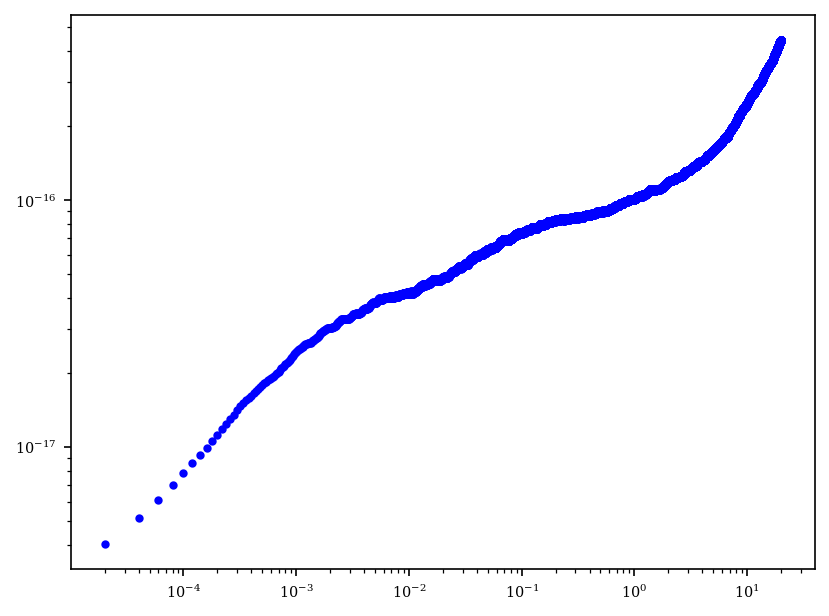

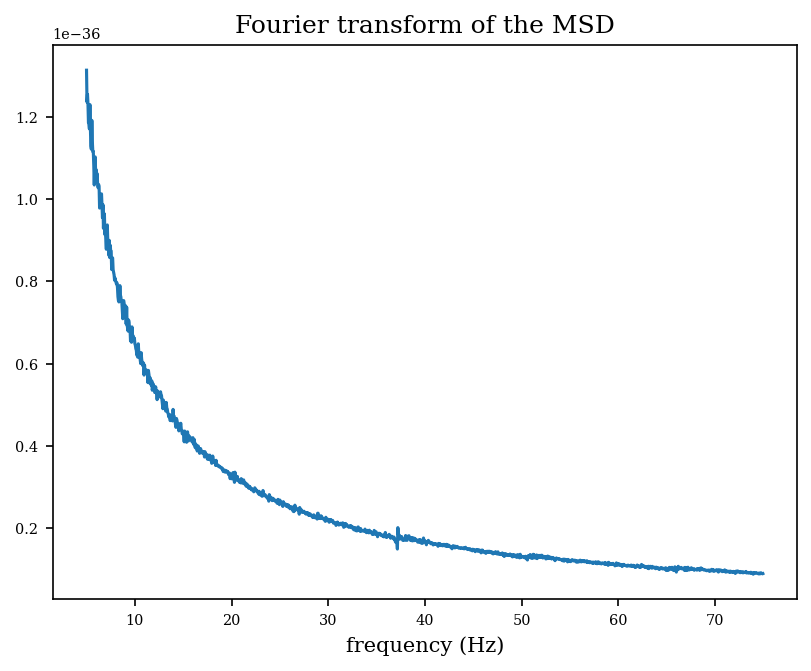

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


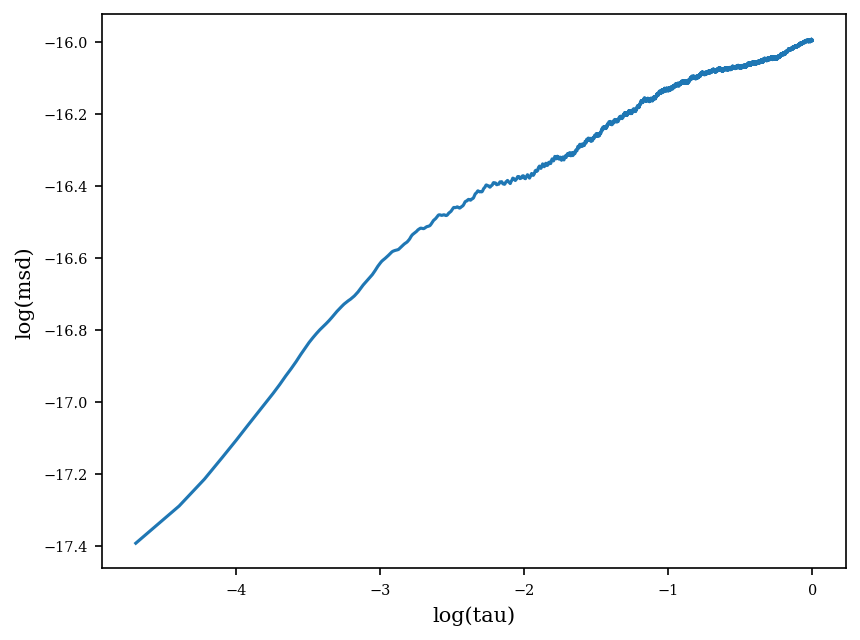

<ipython-input-12-7d861003f092>:86: RuntimeWarning: invalid value encountered in scalar divide
  slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])


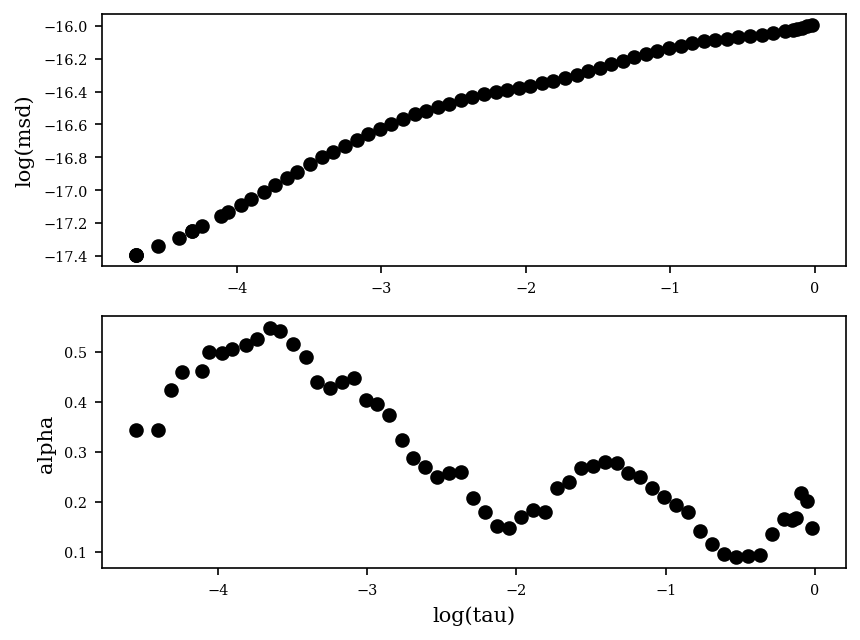

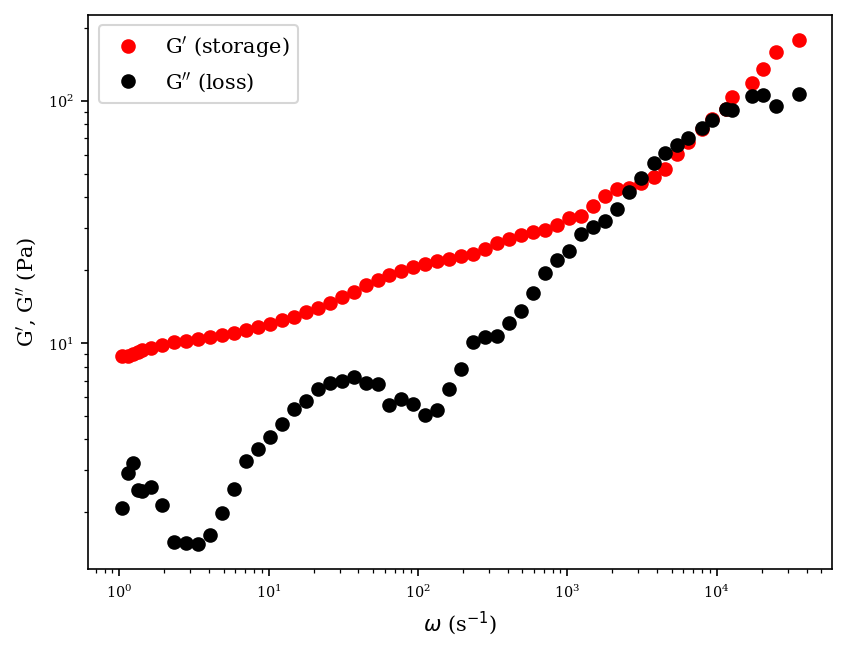

In [ ]:
from scipy import signal

pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'

def calcmsd2(x, y, analysislength, msdlength):

    dt = 1/50000
    fs = 50000
  # Select data to analyze MSD and fourier transform
    xdata = x[0:int(analysislength/dt)]
    ydata = y[0:int(analysislength/dt)]

    msdvalues = msd_fft(xdata, ydata)
    tautemp = msdvalues.tau
    msdtemp = msdvalues.msd
    msdvalues.tau = tautemp[0:int(msdlength/dt)]
    msdvalues.msd = msdtemp[0:int(msdlength/dt)]

    plt.figure()
    plt.loglog(msdvalues.tau[1:int(msdlength/(dt))], msdvalues.msd[1:int(msdlength/(dt))], 'b.')
    plt.figure()
    msddata = np.array(msdvalues.msd[1:int(msdlength/dt)]) / (1e18)
    N = len(msddata)
    T = 1/fs
    yf = fft(msddata)
    xf = fftfreq(N, T)[:N//2]

    print(len(xf))
    print(len(yf))
    plt.plot(xf[100:1500], 2.0/N * np.abs(yf[100:1500]))
    plt.xlabel('frequency (Hz)')
    plt.title('Fourier transform of the MSD')
    plt.show()
    return msdvalues

msdave = np.zeros(int(0.1*fs))
x, y, sumsignal, fg= loaddataquiet('bead4p-nt/bead4-nt_', 0, 120, 0) # output is in m

msdvalues = calcmsd2(x, y, 120, 20) # Analyze the first 120 s, calculating the MSD for a maximum tau of 20 s
msdvaluesdata1 =  msdvalues
# initialize a list
alpha_list = []
omega_list = []
logtau_list = []
logmsd_list = []
tau_list = []
msd_list = []
analysislength = 1

def linear_alpha(x,m,b):
    return m*x+b

N = 0.4 #iteration step

logmsd = np.log10(msdvaluesdata1.msd[:int(analysislength*fs)])
logtau = np.log10(msdvaluesdata1.tau[:int(analysislength*fs)])
msd = (msdvaluesdata1.msd[:int(analysislength*fs)])
tau = (msdvaluesdata1.tau[:int(analysislength*fs)])

plt.figure()
plt.plot(logtau, logmsd)
plt.xlabel('log(tau)')
plt.ylabel('log(msd)')
plt.show()

for i in np.arange(-5, np.log10(5)-N, N/5):

    index = (logtau > i) * (logtau <i+N)
    logmsdsel = (logmsd[index])
    logtausel = (logtau[index])

    msdsel = msd[index]
    tausel = tau[index]

    n = len(tausel)

    logmsd_list.append(np.mean(logmsdsel))
    logtau_list.append(np.mean(logtausel))
    msd_list.append(np.mean(msdsel))
    tau_list.append(np.mean(tausel))

    omega_list.append(1/(10**(logtau_list[-1])))

    # METHOD 2 for calculating the slope
    if len(logmsd_list)>1:
        slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])
    else:
        slope = float("NaN")

    alpha_list.append(slope)

# DAVID: This plot shows us ln(msd) vs ln(tau) on the top.  The alpha curve on the bottom should be the slope of this curve
#   You may notice that the slope looks like it was calculated really well for the first part of the curve, but as we
#   move to the right, and the slope approaches zero, our calculation of the slope is  noisy
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(logtau_list, logmsd_list, 'ko')
plt.ylabel('log(msd)')

plt.subplot(2, 1, 2)
plt.plot(logtau_list, alpha_list, 'ko')
plt.ylabel('alpha')
plt.xlabel('log(tau)')
plt.show()

logtau_list_data = logtau_list
logmsd_list_data = logmsd_list

#CONSTANTS
d = 2 # number of dimensions (x and y)
T = 293.15 # room temp --> 20 celcius = 293.15 Kelvin
K_B = 1.3806e-23 # Boltzmann Constant J/K
radius = (2.0e-6)/2  # radius of the bead, we used 2.01 um diameter beads, multiplied by 10^-6 to get in meters (m)
kBT = 4.11e-21 # room temp * Boltzmann Const.

#lists
Greals2 = [] #list for all G'
Gimags2 = [] #List for all G''
Gstar_primes2 = []
Gstar_Dprimes2 = []
Gstars2 = []
#omegafinal2 = [];
for i in range (1, len(alpha_list)):
    #ω = 1 / tau[i]
    #msd = msd[i]
    #αω = αω[i-1]
    gamma = (0.457*(1+alpha_list[i])**2) - (1.36*(1+alpha_list[i])) + 1.9 #approx value from Mason 2000 p.373 below eqn. 8
    Gstar2 = abs((2*d*K_B*T) / (6*np.pi*radius*msd_list[i]*gamma))
    Gstars2.append(Gstar2)
    Gstar_prime2 = Gstar2 * np.cos((np.pi*alpha_list[i])/2)
    Gstar_Dprime2 = Gstar2 * np.sin((np.pi*alpha_list[i])/2)
    Gstar_primes2.append(Gstar_prime2)
    Gstar_Dprimes2.append(Gstar_Dprime2)

    ktrap = (kx+ky)/2
    offset =  ktrap/(6*np.pi*(1e-6))

    # DAVID: you need to subtract k / (6*pi*a) (kept in SI units)
    Greal2 = Gstar_prime2 #- offset # G' is subtracted by stiffness of the trap because it is the real component
    Gimag2 = Gstar_Dprime2
    Greals2.append(Greal2)
    Gimags2.append(Gimag2)
    #omegafinal2.append(1/msdvaluesdata1.tau[i])

plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')
plt.rcParams['figure.dpi']= 150

Greals2 = np.array(Greals2)
Gimags2 = np.array(Gimags2)

plt.figure()
plt.loglog(omega_list[1:], Greals2, 'ro', label='G$^\prime$ (storage)')
plt.loglog(omega_list[1:], Gimags2, 'ko', label='G$^{\prime\prime}$ (loss)')

plt.xlabel(r'$\omega$ (s$^{-1}$)')
plt.ylabel(r'G$^\prime$, G$^{\prime\prime}$ (Pa)')
plt.legend()
plt.show()

Gprime_4p = Greals2
Gprimeprime_4p = Gimags2
omegalist_4p = omega_list


Bead 5: 5p-nt

499999
999998


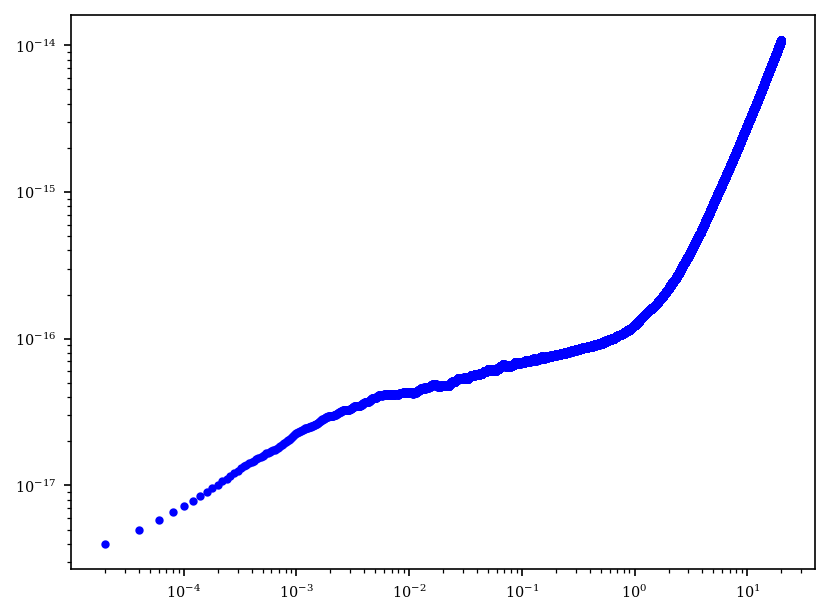

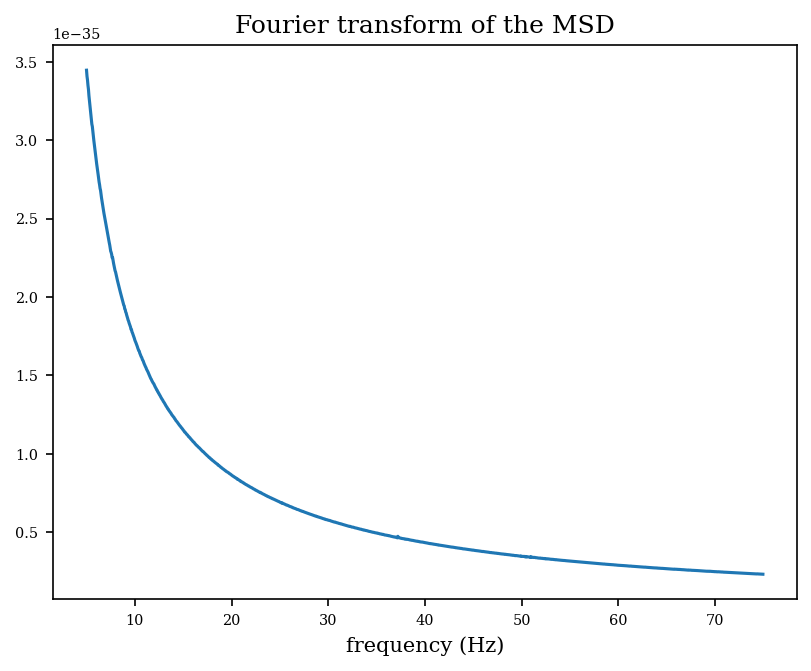

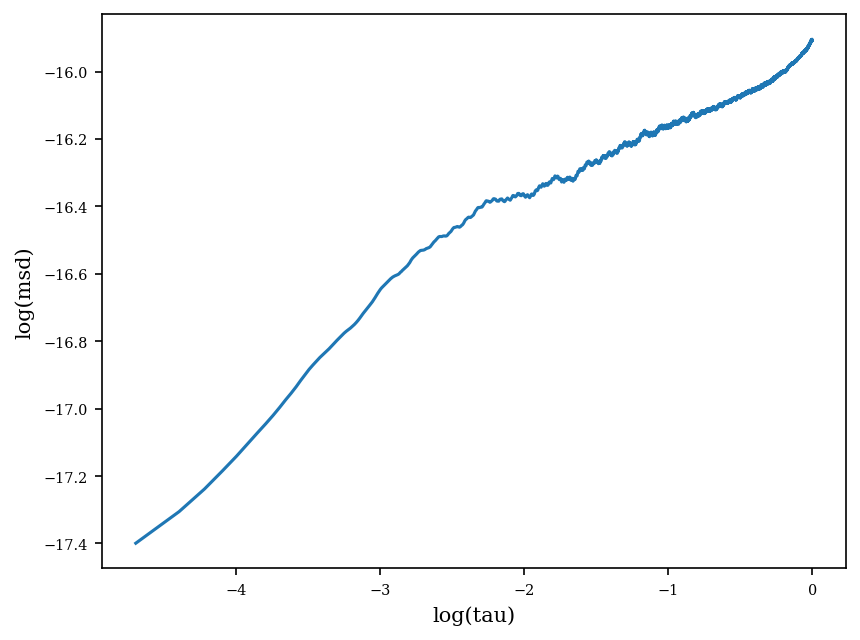

<ipython-input-8-6b60eea7c45f>:86: RuntimeWarning: invalid value encountered in scalar divide
  slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])


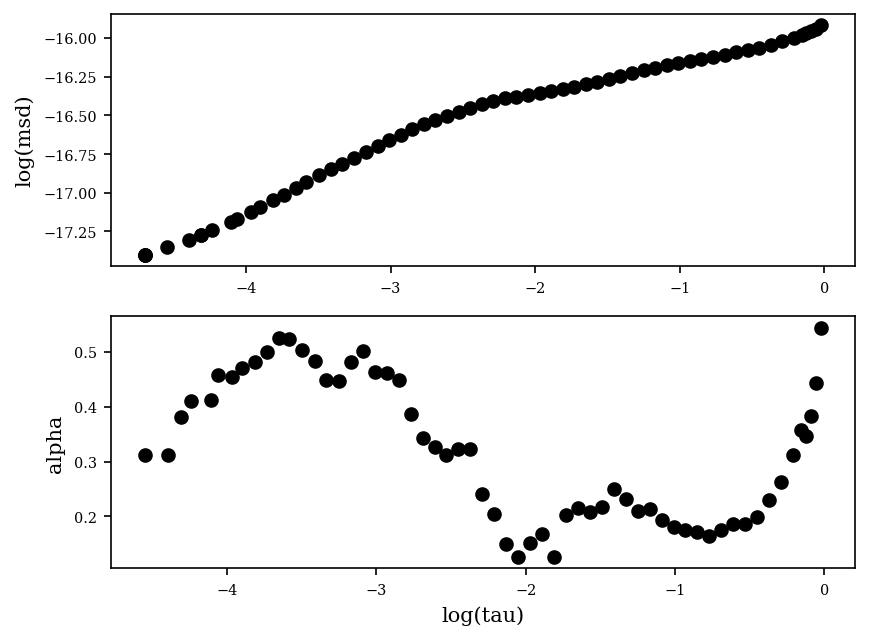

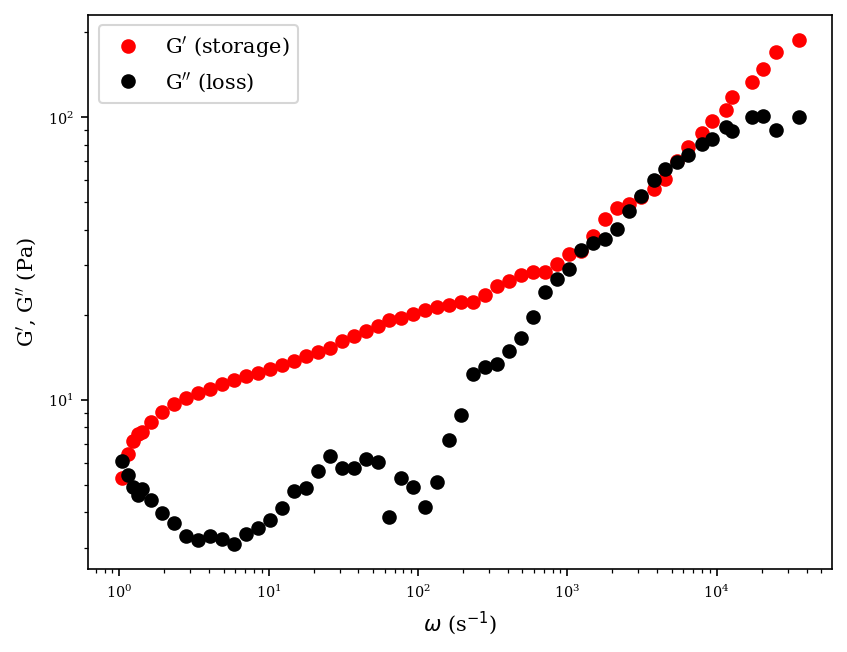

In [ ]:
from scipy import signal

pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'

def calcmsd2(x, y, analysislength, msdlength):

    dt = 1/50000
    fs = 50000
  # Select data to analyze MSD and fourier transform
    xdata = x[0:int(analysislength/dt)]
    ydata = y[0:int(analysislength/dt)]

    msdvalues = msd_fft(xdata, ydata)
    tautemp = msdvalues.tau
    msdtemp = msdvalues.msd
    msdvalues.tau = tautemp[0:int(msdlength/dt)]
    msdvalues.msd = msdtemp[0:int(msdlength/dt)]

    plt.figure()
    plt.loglog(msdvalues.tau[1:int(msdlength/(dt))], msdvalues.msd[1:int(msdlength/(dt))], 'b.')
    plt.figure()
    msddata = np.array(msdvalues.msd[1:int(msdlength/dt)]) / (1e18)
    N = len(msddata)
    T = 1/fs
    yf = fft(msddata)
    xf = fftfreq(N, T)[:N//2]

    print(len(xf))
    print(len(yf))
    plt.plot(xf[100:1500], 2.0/N * np.abs(yf[100:1500]))
    plt.xlabel('frequency (Hz)')
    plt.title('Fourier transform of the MSD')
    plt.show()
    return msdvalues

msdave = np.zeros(int(0.1*fs))
x, y, sumsignal, fg= loaddataquiet('bead5p-nt/bead5p-nt_', 0, 60, 0) # output is in m

msdvalues = calcmsd2(x, y, 60, 20) # Analyze the first 120 s, calculating the MSD for a maximum tau of 20 s
msdvaluesdata1 =  msdvalues
# initialize a list
alpha_list = []
omega_list = []
logtau_list = []
logmsd_list = []
tau_list = []
msd_list = []
analysislength = 1

def linear_alpha(x,m,b):
    return m*x+b

N = 0.4 #iteration step

logmsd = np.log10(msdvaluesdata1.msd[:int(analysislength*fs)])
logtau = np.log10(msdvaluesdata1.tau[:int(analysislength*fs)])
msd = (msdvaluesdata1.msd[:int(analysislength*fs)])
tau = (msdvaluesdata1.tau[:int(analysislength*fs)])

plt.figure()
plt.plot(logtau, logmsd)
plt.xlabel('log(tau)')
plt.ylabel('log(msd)')
plt.show()

for i in np.arange(-5, np.log10(5)-N, N/5):

    index = (logtau > i) * (logtau <i+N)
    logmsdsel = (logmsd[index])
    logtausel = (logtau[index])

    msdsel = msd[index]
    tausel = tau[index]

    n = len(tausel)

    logmsd_list.append(np.mean(logmsdsel))
    logtau_list.append(np.mean(logtausel))
    msd_list.append(np.mean(msdsel))
    tau_list.append(np.mean(tausel))

    omega_list.append(1/(10**(logtau_list[-1])))

    # METHOD 2 for calculating the slope
    if len(logmsd_list)>1:
        slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])
    else:
        slope = float("NaN")

    alpha_list.append(slope)

# DAVID: This plot shows us ln(msd) vs ln(tau) on the top.  The alpha curve on the bottom should be the slope of this curve
#   You may notice that the slope looks like it was calculated really well for the first part of the curve, but as we
#   move to the right, and the slope approaches zero, our calculation of the slope is  noisy
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(logtau_list, logmsd_list, 'ko')
plt.ylabel('log(msd)')

plt.subplot(2, 1, 2)
plt.plot(logtau_list, alpha_list, 'ko')
plt.ylabel('alpha')
plt.xlabel('log(tau)')
plt.show()

logtau_list_data = logtau_list
logmsd_list_data = logmsd_list

#CONSTANTS
d = 2 # number of dimensions (x and y)
T = 293.15 # room temp --> 20 celcius = 293.15 Kelvin
K_B = 1.3806e-23 # Boltzmann Constant J/K
radius = (2.0e-6)/2  # radius of the bead, we used 2.01 um diameter beads, multiplied by 10^-6 to get in meters (m)
kBT = 4.11e-21 # room temp * Boltzmann Const.

#lists
Greals2 = [] #list for all G'
Gimags2 = [] #List for all G''
Gstar_primes2 = []
Gstar_Dprimes2 = []
Gstars2 = []
#omegafinal2 = [];
for i in range (1, len(alpha_list)):
    #ω = 1 / tau[i]
    #msd = msd[i]
    #αω = αω[i-1]
    gamma = (0.457*(1+alpha_list[i])**2) - (1.36*(1+alpha_list[i])) + 1.9 #approx value from Mason 2000 p.373 below eqn. 8
    Gstar2 = abs((2*d*K_B*T) / (6*np.pi*radius*msd_list[i]*gamma))
    Gstars2.append(Gstar2)
    Gstar_prime2 = Gstar2 * np.cos((np.pi*alpha_list[i])/2)
    Gstar_Dprime2 = Gstar2 * np.sin((np.pi*alpha_list[i])/2)
    Gstar_primes2.append(Gstar_prime2)
    Gstar_Dprimes2.append(Gstar_Dprime2)

    ktrap = (kx+ky)/2
    offset =  ktrap/(6*np.pi*(1e-6))

    # DAVID: you need to subtract k / (6*pi*a) (kept in SI units)
    Greal2 = Gstar_prime2 #- offset # G' is subtracted by stiffness of the trap because it is the real component
    Gimag2 = Gstar_Dprime2
    Greals2.append(Greal2)
    Gimags2.append(Gimag2)
    #omegafinal2.append(1/msdvaluesdata1.tau[i])

plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')
plt.rcParams['figure.dpi']= 150

Greals2 = np.array(Greals2)
Gimags2 = np.array(Gimags2)

plt.figure()
plt.loglog(omega_list[1:], Greals2, 'ro', label='G$^\prime$ (storage)')
plt.loglog(omega_list[1:], Gimags2, 'ko', label='G$^{\prime\prime}$ (loss)')

plt.xlabel(r'$\omega$ (s$^{-1}$)')
plt.ylabel(r'G$^\prime$, G$^{\prime\prime}$ (Pa)')
plt.legend()
plt.show()

Gprime_5p = Greals2
Gprimeprime_5p = Gimags2
omegalist_5p = omega_list


# Active microrheology analysis
## Each separate bead has its own cell

Bead 4 - not very responsive

Original frequency:  1.0   FG frequency:  0.9313208352540993  ratio =  0.9313208352540993


<Figure size 640x480 with 0 Axes>

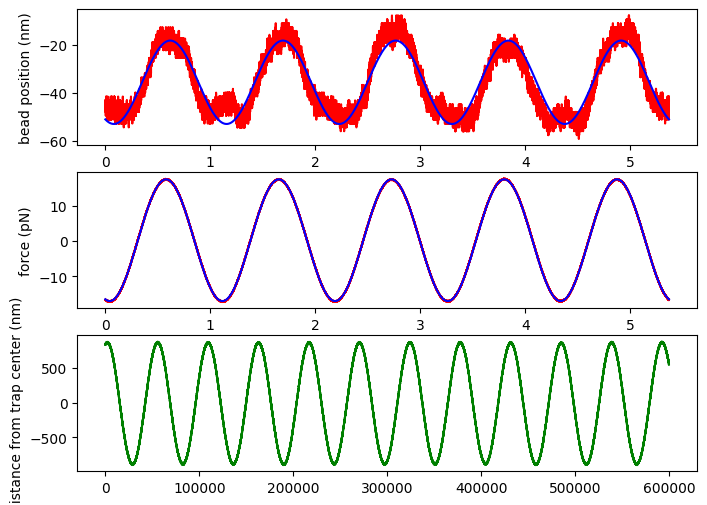

Original frequency:  2.0   FG frequency:  1.8626353770895898  ratio =  0.9313176885447949


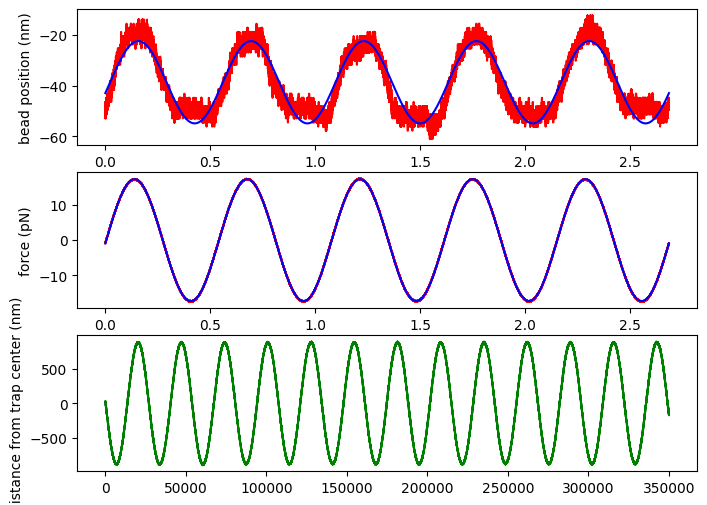

Original frequency:  3.0   FG frequency:  2.980216470441036  ratio =  0.993405490147012


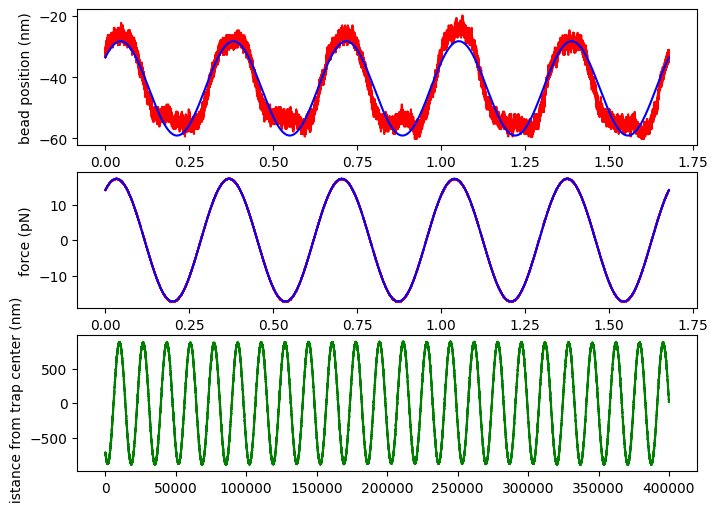

Original frequency:  4.0   FG frequency:  3.9115318058601924  ratio =  0.9778829514650481


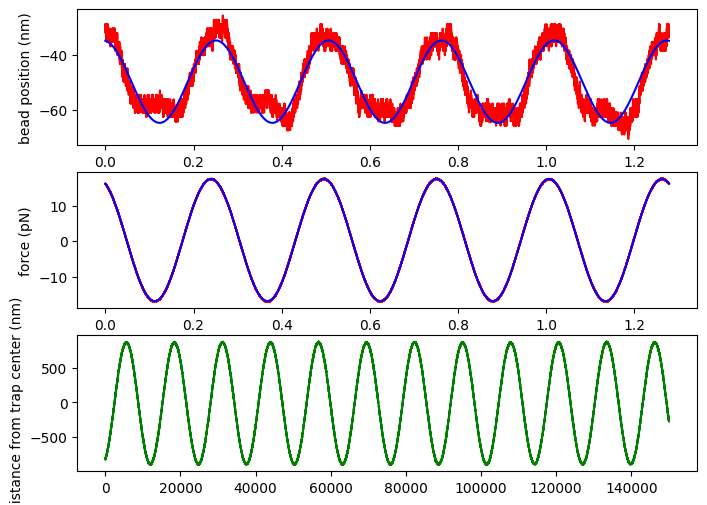

Original frequency:  5.0   FG frequency:  4.842858436585984  ratio =  0.9685716873171968


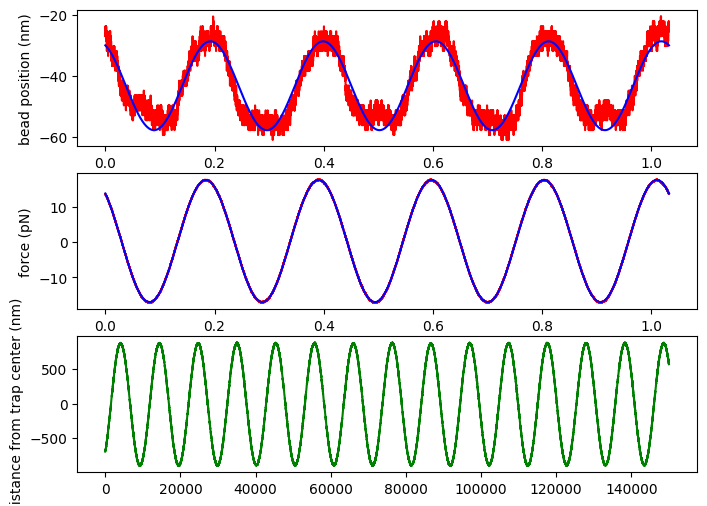

Original frequency:  6.0   FG frequency:  5.960417418291205  ratio =  0.9934029030485342


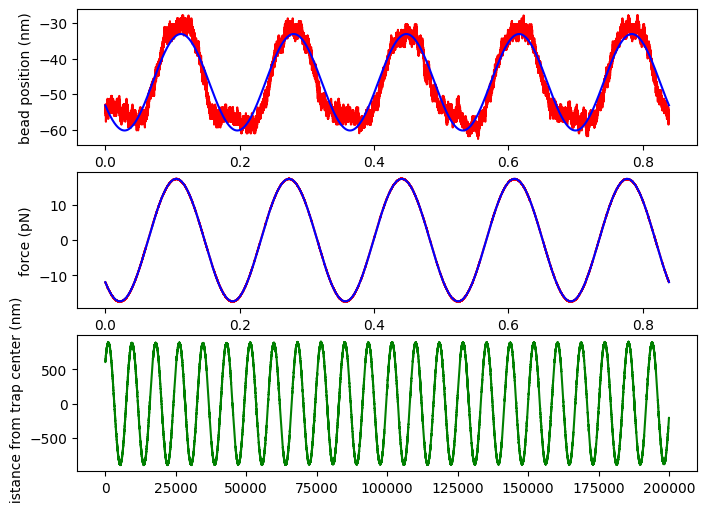

Original frequency:  7.0   FG frequency:  6.891751278249322  ratio =  0.9845358968927603


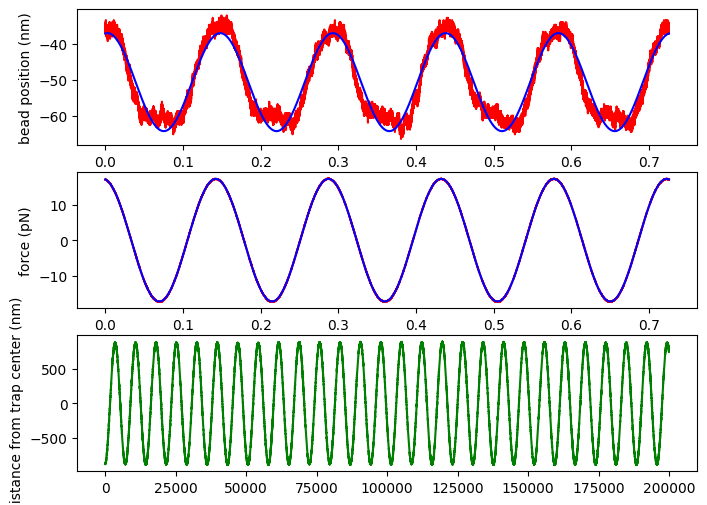

Original frequency:  8.0   FG frequency:  7.823091691473093  ratio =  0.9778864614341366


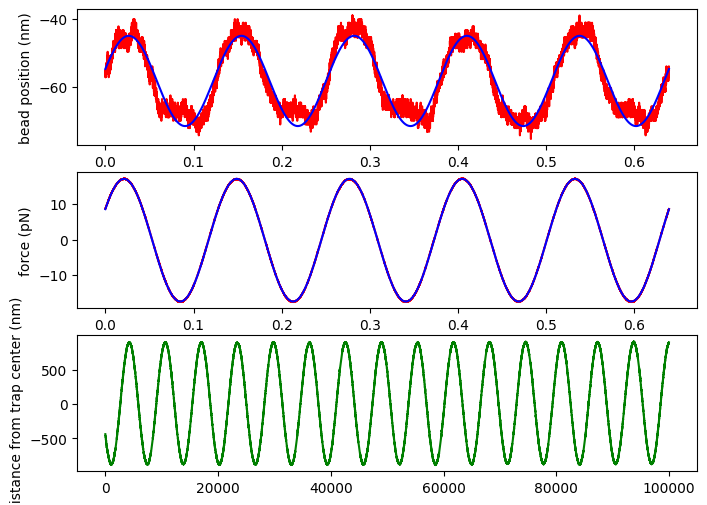

Original frequency:  9.0   FG frequency:  8.940643212410933  ratio =  0.9934048013789926


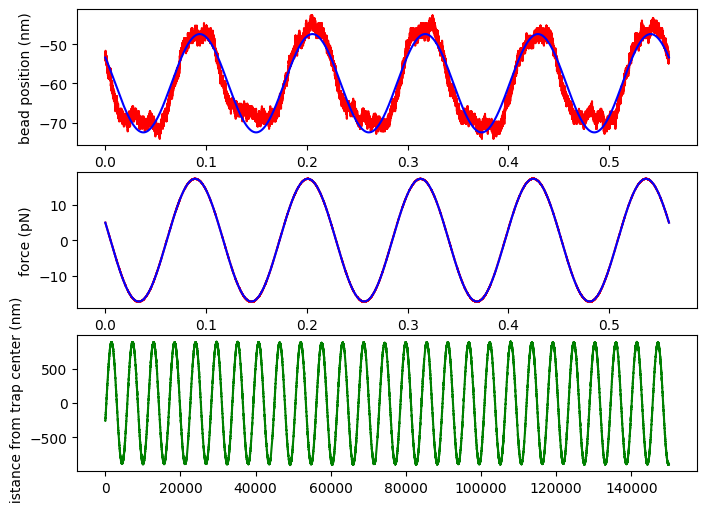

Original frequency:  10.0   FG frequency:  9.871950997328538  ratio =  0.9871950997328538


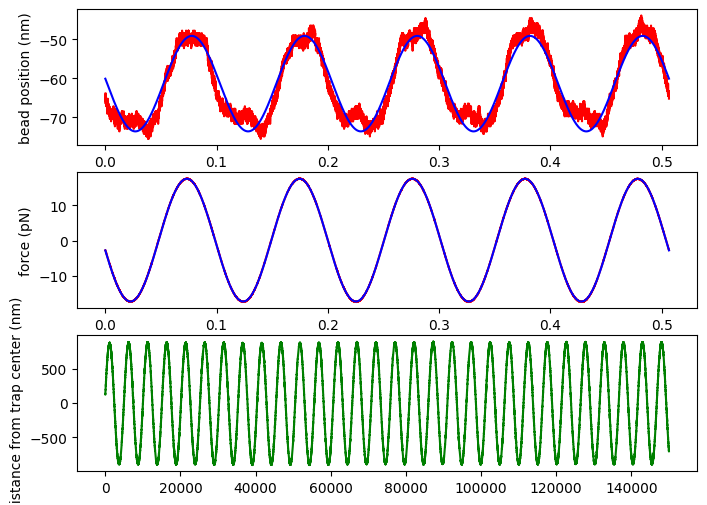

Original frequency:  20.0   FG frequency:  19.930162533409582  ratio =  0.9965081266704792


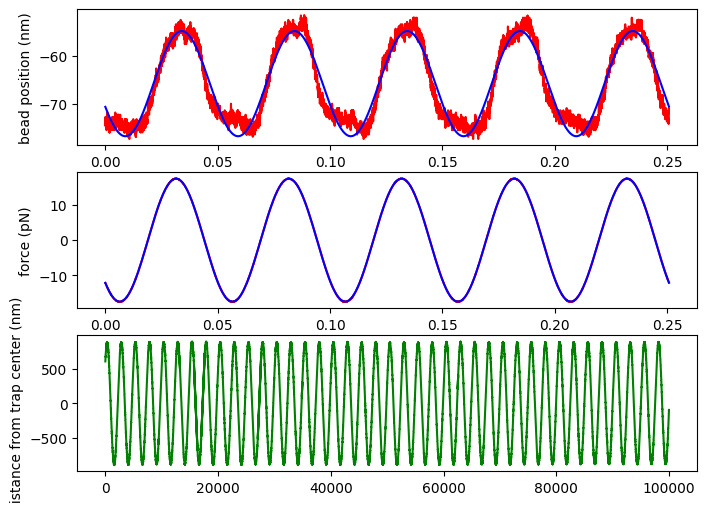

Original frequency:  30.0   FG frequency:  29.988356291724415  ratio =  0.9996118763908138


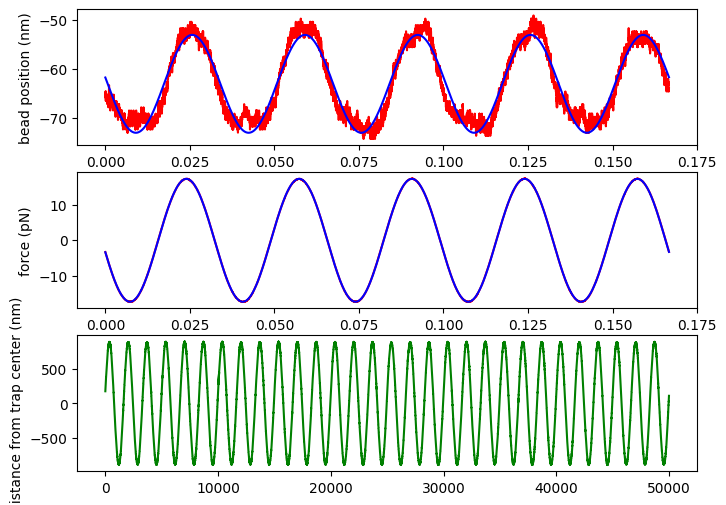

Original frequency:  40.0   FG frequency:  39.860412601758846  ratio =  0.9965103150439711


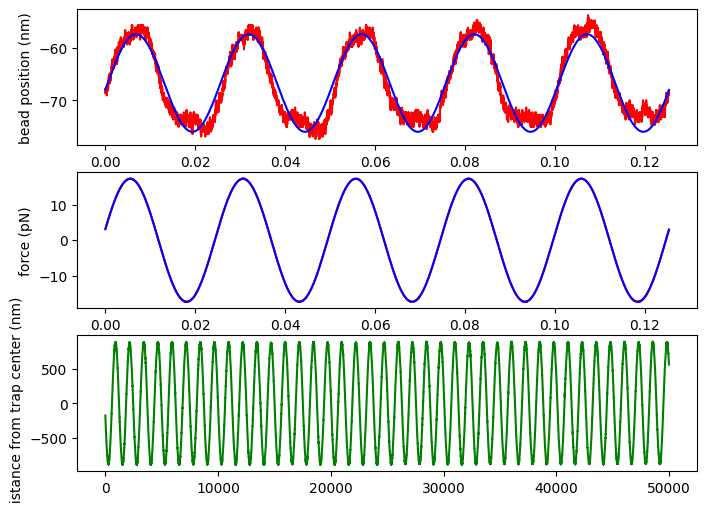

Original frequency:  50.0   FG frequency:  49.91860983122924  ratio =  0.9983721966245848


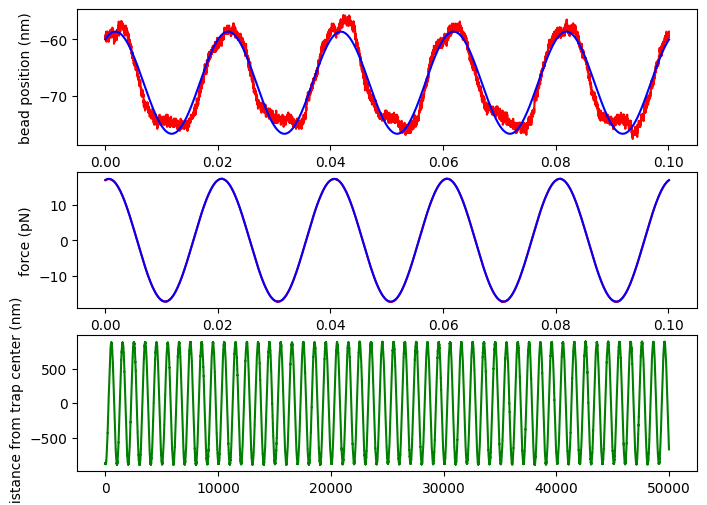

Original frequency:  60.0   FG frequency:  59.97674372459005  ratio =  0.9996123954098342


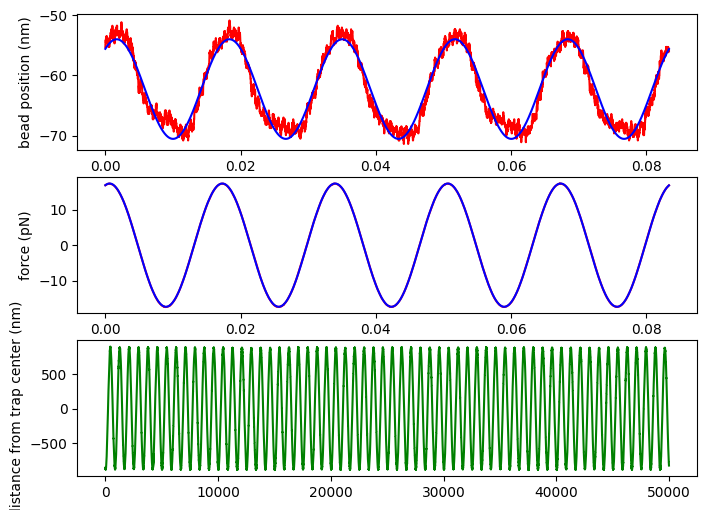

Original frequency:  70.0   FG frequency:  69.84874235283651  ratio =  0.997839176469093


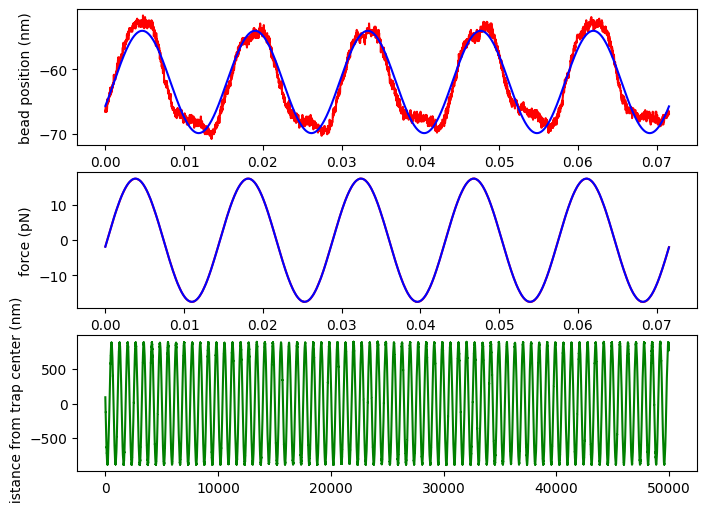

Original frequency:  80.0   FG frequency:  79.90695812558107  ratio =  0.9988369765697633


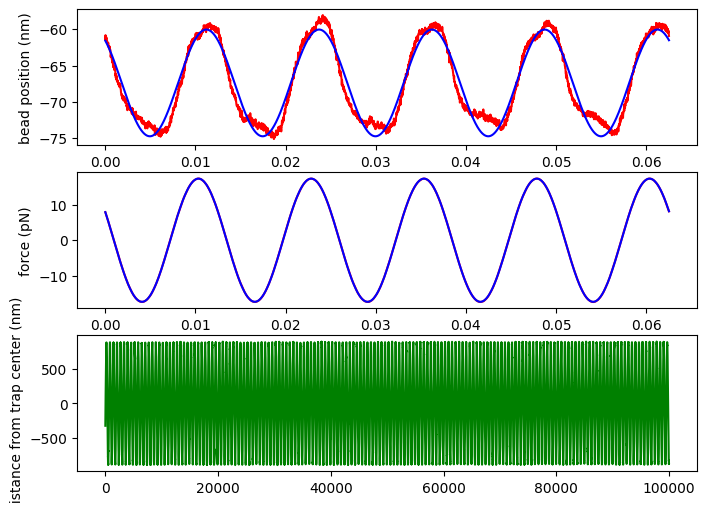

Original frequency:  100.0   FG frequency:  99.8371357531831  ratio =  0.998371357531831


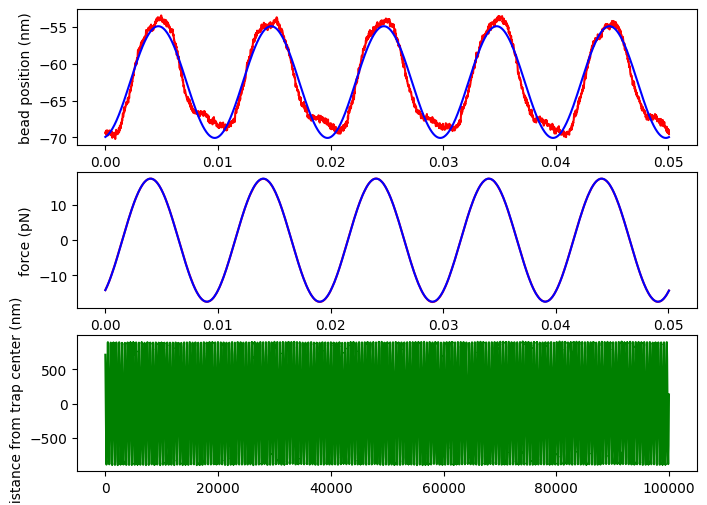

Original frequency:  200.0   FG frequency:  199.8605344595605  ratio =  0.9993026722978026


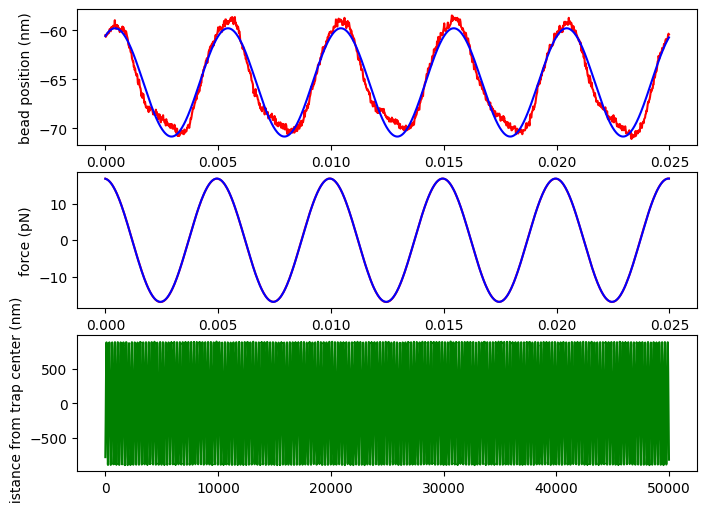

Original frequency:  300.0   FG frequency:  299.8839394389345  ratio =  0.9996131314631149


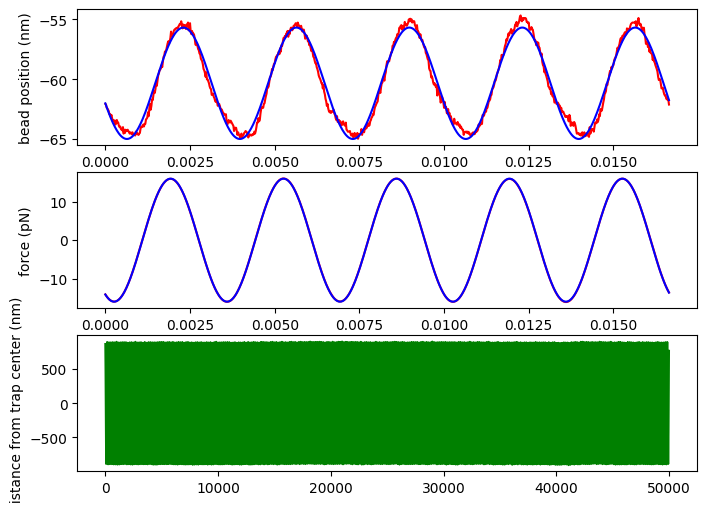

Original frequency:  400.0   FG frequency:  399.9072996772727  ratio =  0.9997682491931817


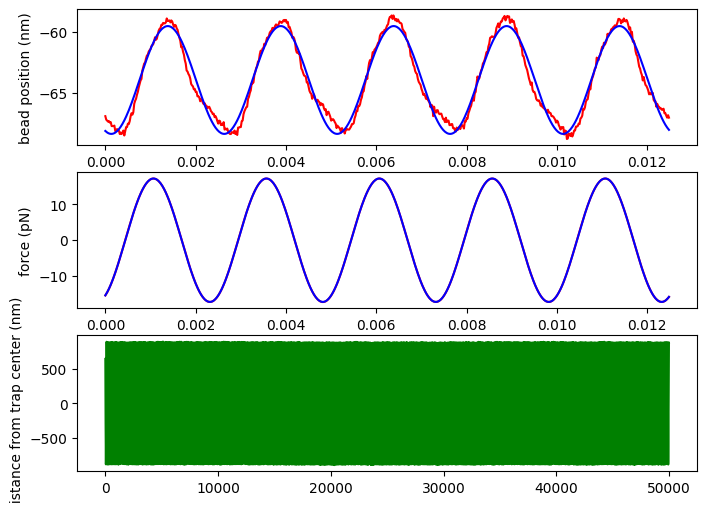

Original frequency:  600.0   FG frequency:  599.9540795413507  ratio =  0.9999234659022511


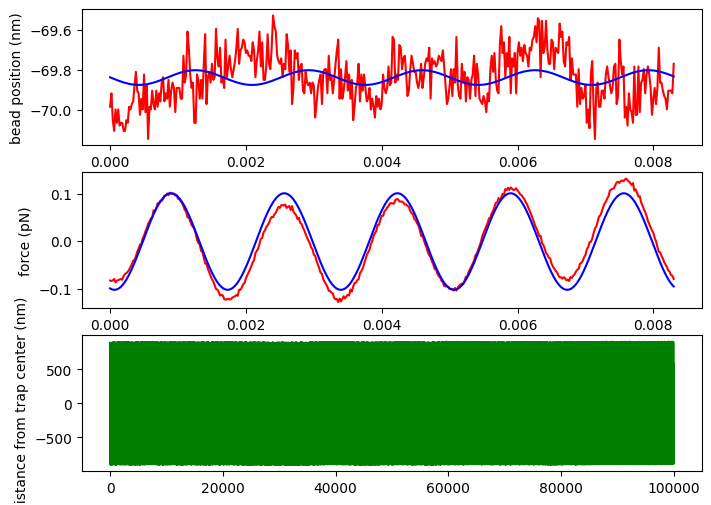

Original frequency:  700.0   FG frequency:  699.9774974162605  ratio =  0.9999678534518006


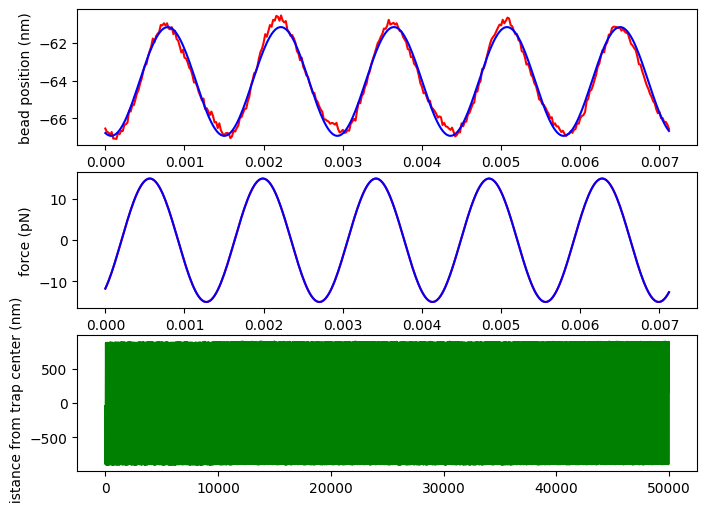

Original frequency:  800.0   FG frequency:  799.8146327169816  ratio =  0.999768290896227


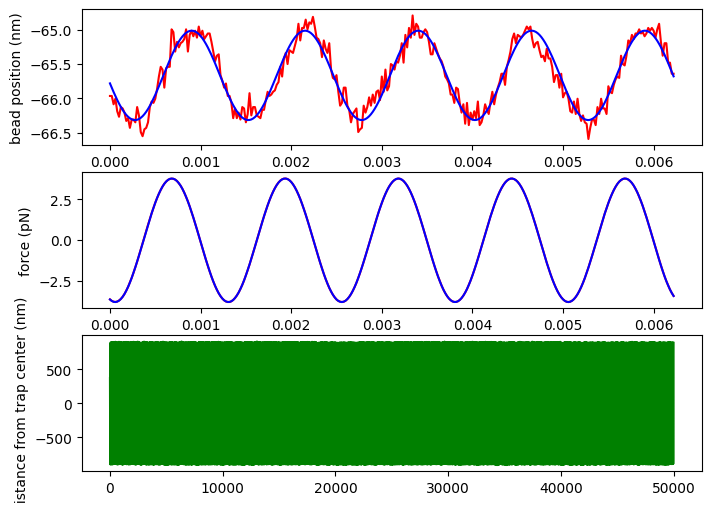

In [ ]:
# This code was updated during Feb 2025

from scipy import optimize
def sinefit(t, A, C, D, omega):
    return np.abs(A) * np.sin(omega*t - C)+D
def sinefit2(omegaoscil):
  def func(t,*p):
    return np.abs(p[0]) * np.sin(omegaoscil*t - p[1])+p[2]
  return func


pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'

plt.figure()
frequencies = np.array([])

for i in range(0, 123):
  y, x, sumsignal, fg= loaddataquiet('bead4/bead4_', i, i+1, 0)
  t = np.arange(0, len(yb)/fs, 1/fs)
  Y = fft(fg)
  N = len(Y)
  n = np.arange(N)
  T = N/fs
  freq = n/T
  index = (freq>0.1)*(freq<20000)
  freqsec = freq[index]
  Ysec = np.abs(Y[index])
  frequencies = np.append(frequencies, freqsec[Ysec == np.max(Ysec)])

changesindex = (np.diff(frequencies)>0.5)
filenumber = np.arange(1, 123, 1)
fn_change = filenumber[changesindex]
frequencies = np.append(1, frequencies[fn_change])

freqlist = np.array([])
Fnot = np.array([])
ynot = np.array([])
delta = np.array([])
for i in range(0, len(fn_change)-1):
  if i == 0:
    x, y, sumsignal, fg= loaddataquiet('bead4/bead4_', 0, fn_change[i]-1, 0)
  else:
    x, y, sumsignal, fg= loaddataquiet('bead4/bead4_', fn_change[i-1]+1, fn_change[i]-1, 0)

  if len(fg) > 0:
    times = np.arange(0, dt*len(y), dt)
    tdata = times
    OTdata = a*fg+b

    fgfit = fg-np.mean(fg)
    #plt.figure()
    #plt.plot(tdata, fg, 'k')
    params, params_covariance = optimize.curve_fit(sinefit, tdata, fgfit, p0=[np.std(fgfit)*np.sqrt(2), 0, 0, 2*np.pi*frequencies[i]])
    if np.abs(np.std(fgfit)*np.sqrt(2)/params[0])>2:
      params, params_covariance = optimize.curve_fit(sinefit, tdata, fgfit, p0=[np.std(fgfit)*np.sqrt(2), np.pi, 0, 2*np.pi*frequencies[i]])
    freqlist = np.append(freqlist, params[3]/(2*np.pi))

    phase = params[1]
    print('Original frequency: ', frequencies[i], '  FG frequency: ', params[3]/(2*np.pi), ' ratio = ', params[3]/(2*np.pi)/frequencies[i])#
    #plt.plot(tdata, sinefit(tdata, *params), 'r--')
    #plt.show()

    y = y*1e9
    Fcurve = -(ky / 1e-12 * 1e-9) * ((y-np.mean(y)) - (OTdata-np.mean(OTdata)))  # in pN
    Noscil = 5
    freqoscil = params[3]/(2*np.pi)
    # FIT the y data

    aveydata = np.zeros(int((Noscil/freqoscil)/dt))
    aveFdata = np.zeros(int((Noscil/freqoscil)/dt))
    count = 0
    for j in range(0, len(y), int((Noscil/freqoscil)/dt)):
      if len(y[j:j+int((Noscil/freqoscil)/dt)]) == len(aveydata):
        count = count+1
        aveydata = aveydata + y[j:j+int((Noscil/freqoscil)/dt)]
        aveFdata = aveFdata + Fcurve[j:j+int((Noscil/freqoscil)/dt)]
        times = dt*np.arange(0, len(y[j:j+int((Noscil/freqoscil)/dt)]), 1)
    aveydata = aveydata/count
    aveFdata = aveFdata/count
    plt.figure(figsize = (8, 6))
    plt.subplot(3, 1, 1)
    plt.plot(times, aveydata, 'r')
    plt.ylabel('bead position (nm)')
    plt.subplot(3, 1, 2)
    plt.plot(times, aveFdata, 'r')
    plt.ylabel('force (pN)')
    plt.xlabel('time (s)')


    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(y)*np.sqrt(2), phase, 0])
    if np.std(y)*np.sqrt(2)/params[0]>2:
      params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(y)*np.sqrt(2), np.pi, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.subplot(3, 1, 1)
    plt.plot(times, sinefit(times, *params), 'b-')
    yphase = params[1]
    ynot = np.append(ynot, params[0]*1e-9)


    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveFdata, p0=[np.std(Fcurve)*np.sqrt(2), 0, 0])
    if np.std(Fcurve)*np.sqrt(2)/params[0]>2 or np.std(Fcurve)*np.sqrt(2)/params[0]<0.5:
      params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveFdata, p0=[np.std(Fcurve)*np.sqrt(2), np.pi, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.subplot(3, 1, 2)
    plt.plot(times, sinefit(times, *params), 'b-')
    plt.subplot(3, 1, 3)
    plt.plot( ((y-np.mean(y)) - (OTdata-np.mean(OTdata))), 'g')
    plt.ylabel('distance from trap center (nm)')




    Fnot = np.append(Fnot, params[0]*1e-12)
    deltatemp = yphase-params[1]
    if deltatemp<0:
      deltatemp = deltatemp+2*np.pi
    delta = np.append(delta, deltatemp)

    plt.show()

Gprime_4a = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.cos(delta)
Gprimeprime_4a = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.sin(delta)


Bead 5: only bead from this day which responded well (all others yielded a very small signal)

<Figure size 640x480 with 0 Axes>

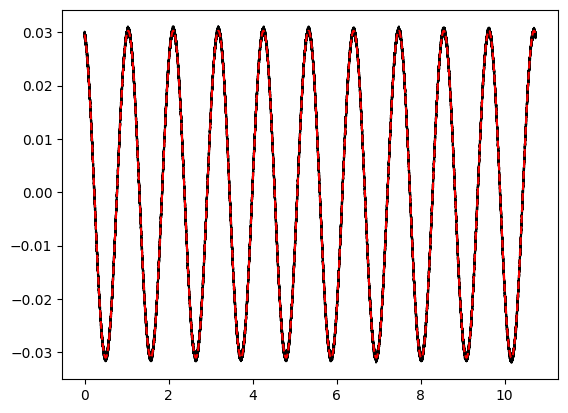

Original frequency:  1.0   FG frequency:  0.9313282330852712  ratio =  0.9313282330852712


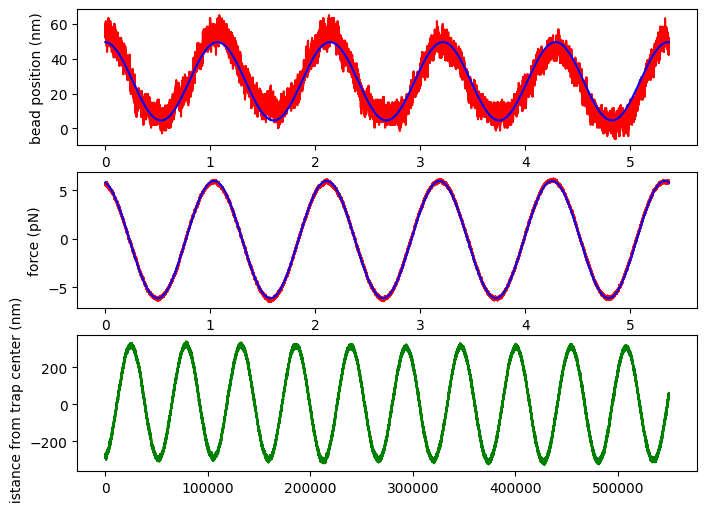

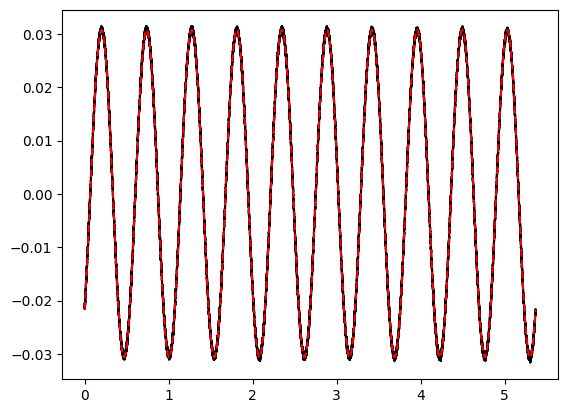

Original frequency:  2.0   FG frequency:  1.8626256113937731  ratio =  0.9313128056968866


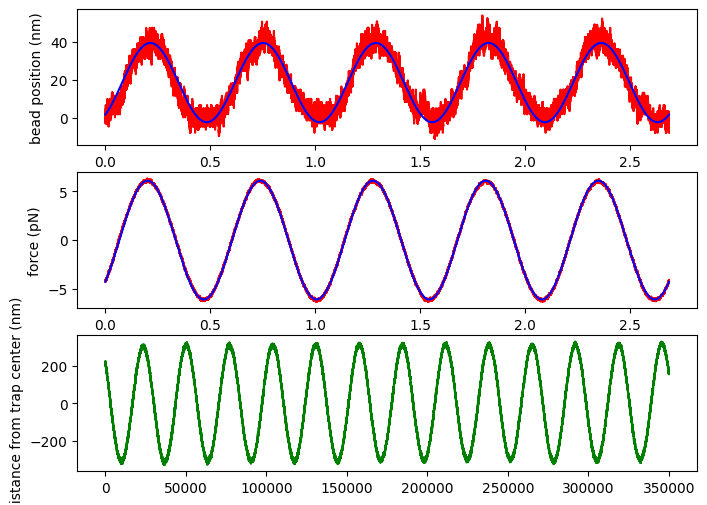

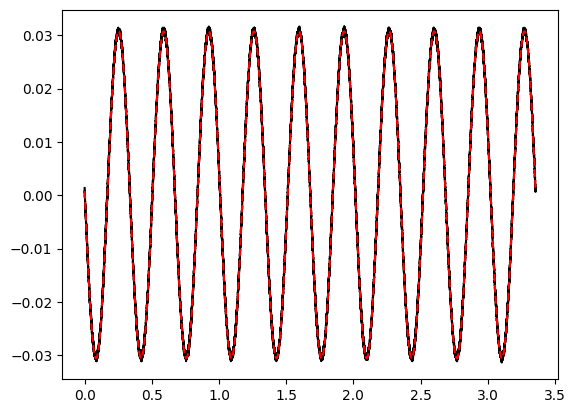

Original frequency:  3.0   FG frequency:  2.980205517170636  ratio =  0.9934018390568786


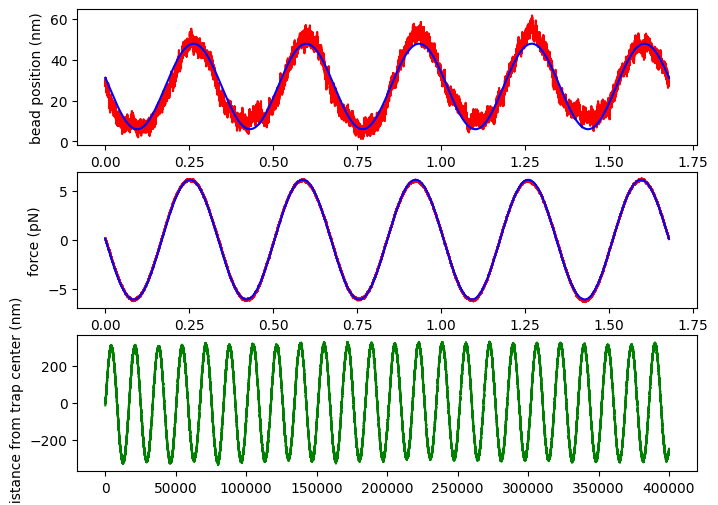

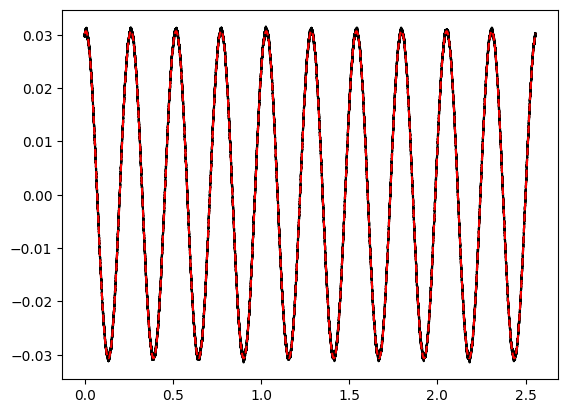

Original frequency:  4.0   FG frequency:  3.9115682879001863  ratio =  0.9778920719750466


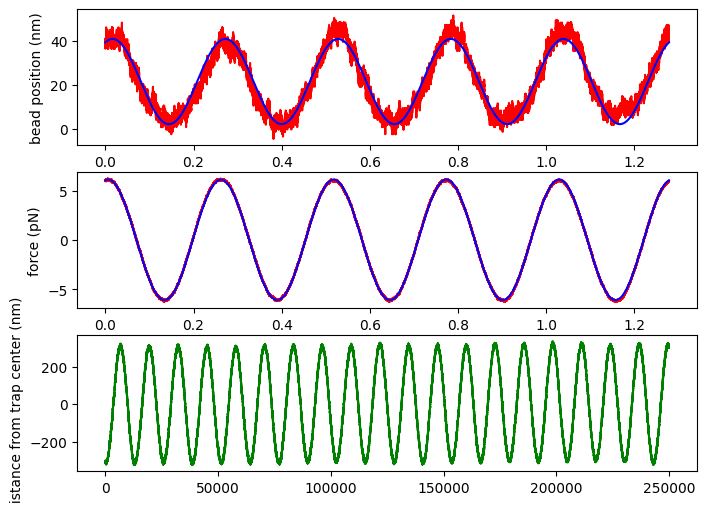

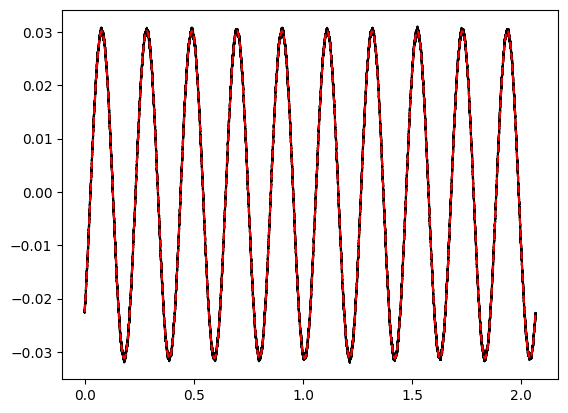

Original frequency:  5.0   FG frequency:  4.842811080261105  ratio =  0.9685622160522209


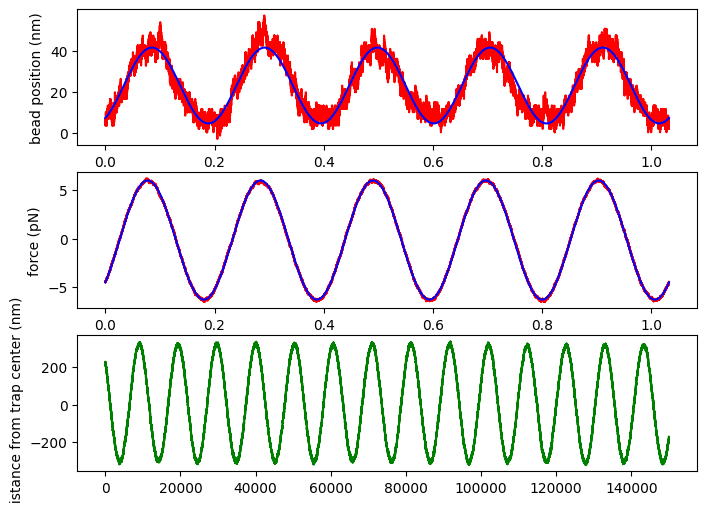

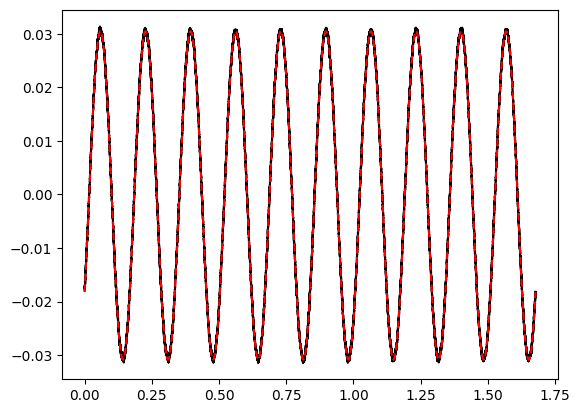

Original frequency:  6.0   FG frequency:  5.960433613899335  ratio =  0.9934056023165558


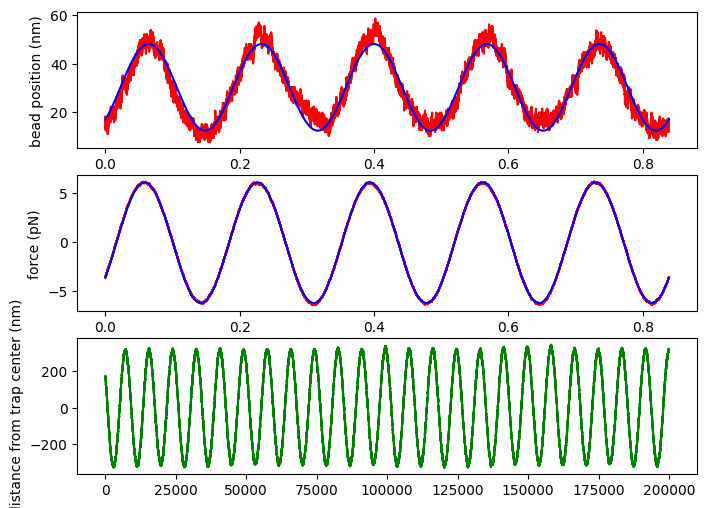

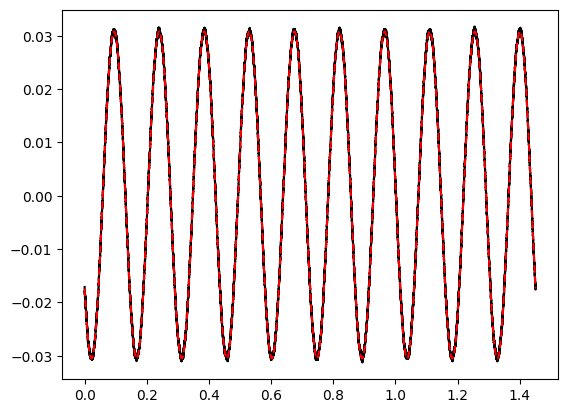

Original frequency:  7.0   FG frequency:  6.891698736413547  ratio =  0.984528390916221


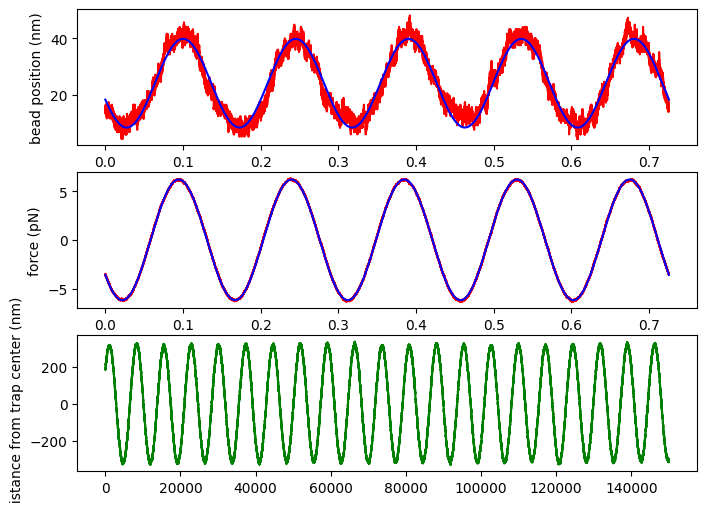

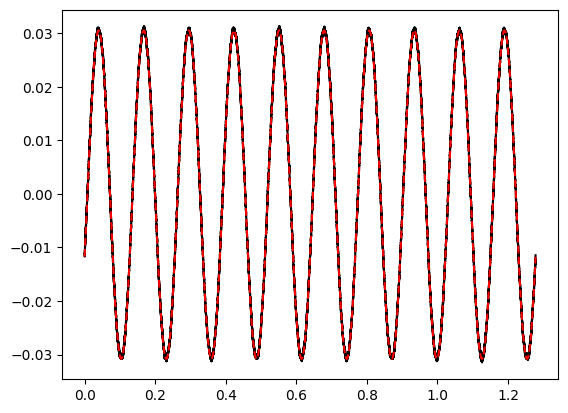

Original frequency:  8.0   FG frequency:  7.823051885897752  ratio =  0.977881485737219


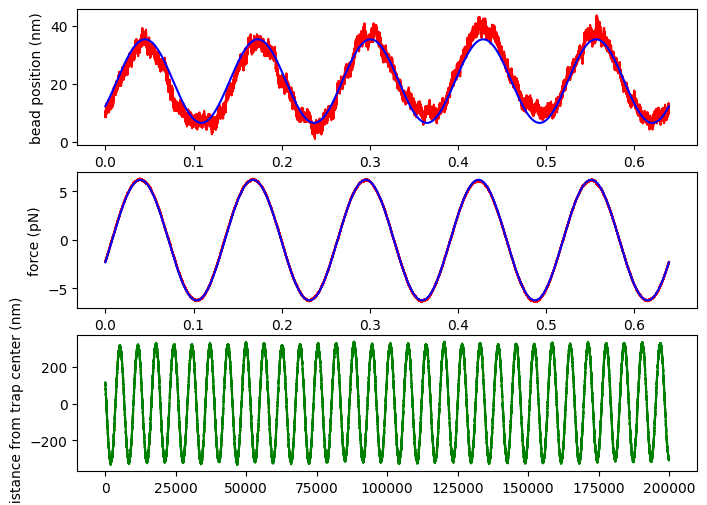

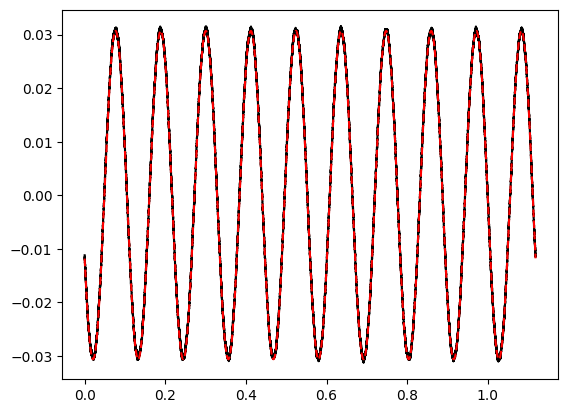

Original frequency:  9.0   FG frequency:  8.940616658985977  ratio =  0.9934018509984419


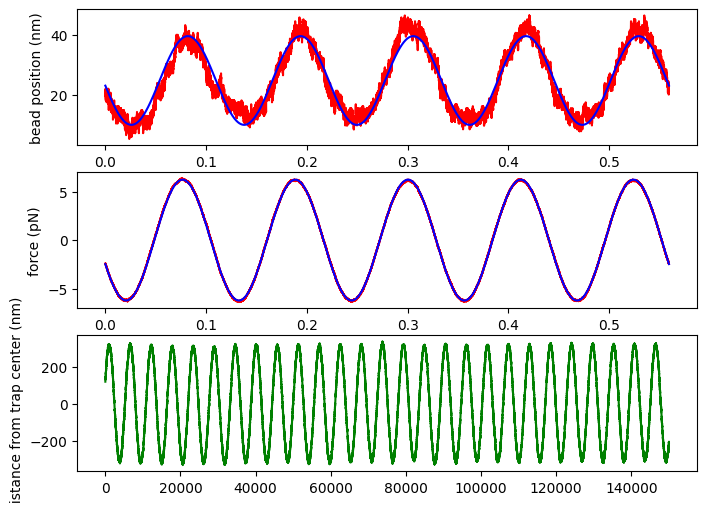

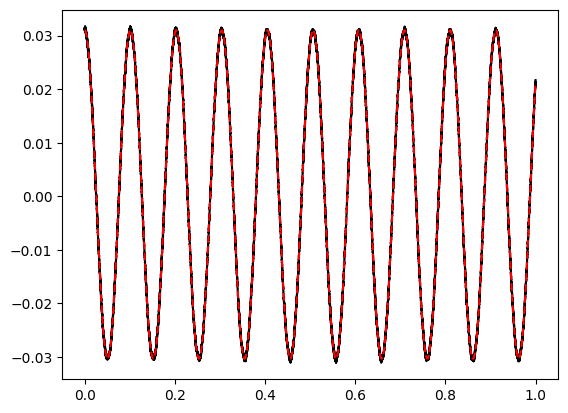

Original frequency:  10.0   FG frequency:  9.871910507798113  ratio =  0.9871910507798113


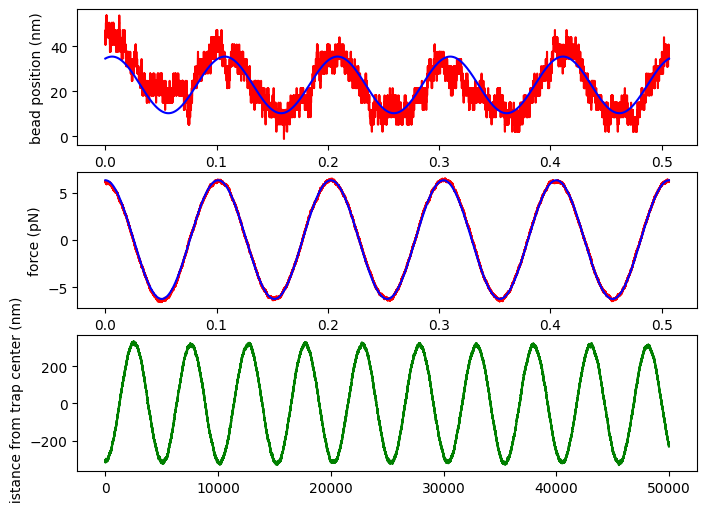

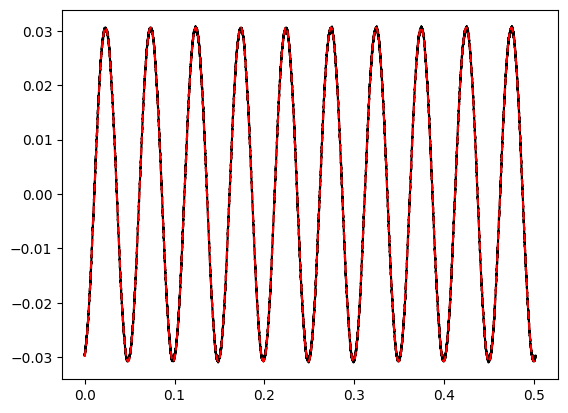

Original frequency:  20.0   FG frequency:  19.930153744737225  ratio =  0.9965076872368612


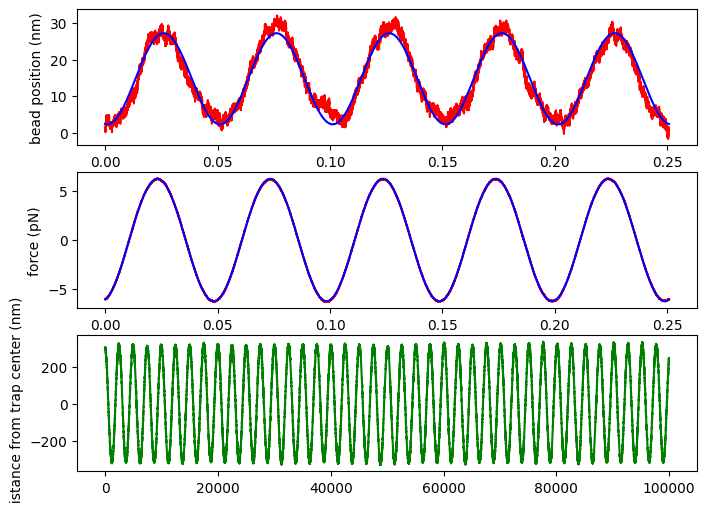

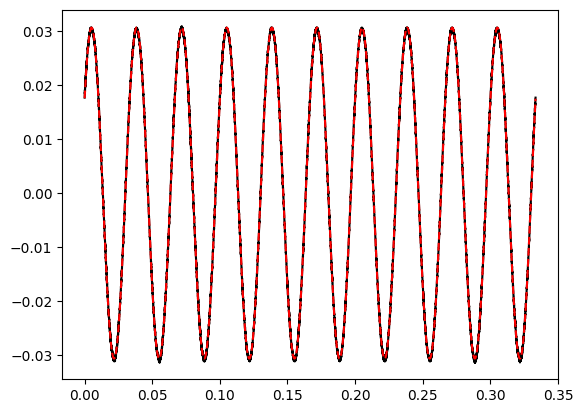

Original frequency:  30.0   FG frequency:  29.98841781856618  ratio =  0.9996139272855393


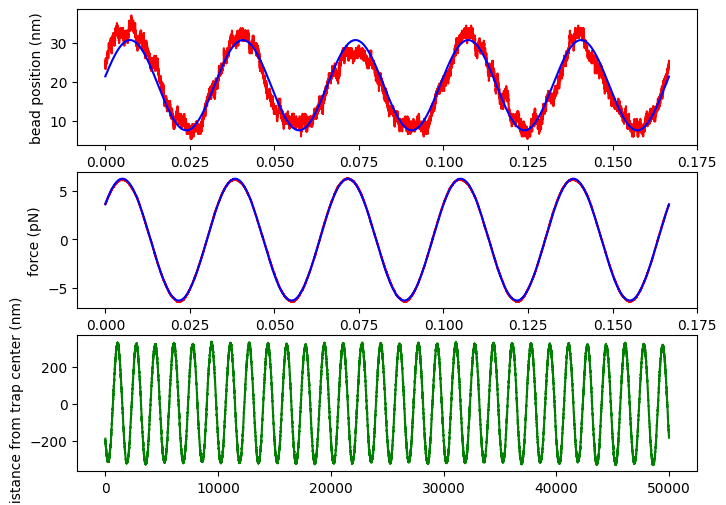

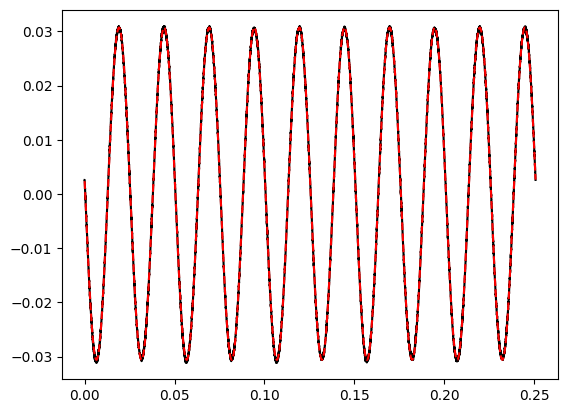

Original frequency:  40.0   FG frequency:  39.86027044087045  ratio =  0.9965067610217613


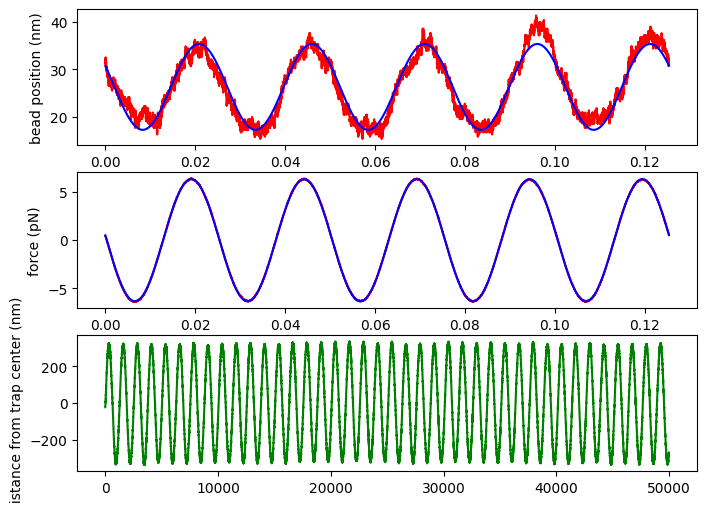

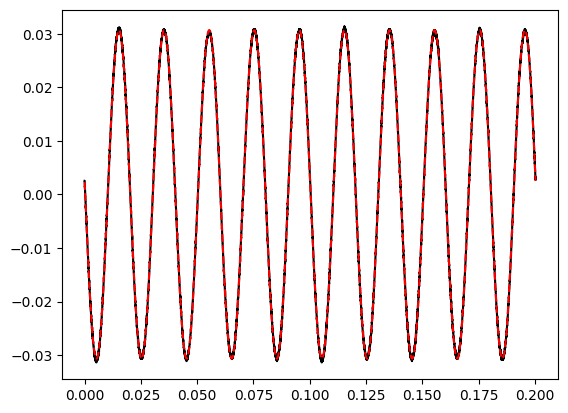

Original frequency:  50.0   FG frequency:  49.91839776078917  ratio =  0.9983679552157834


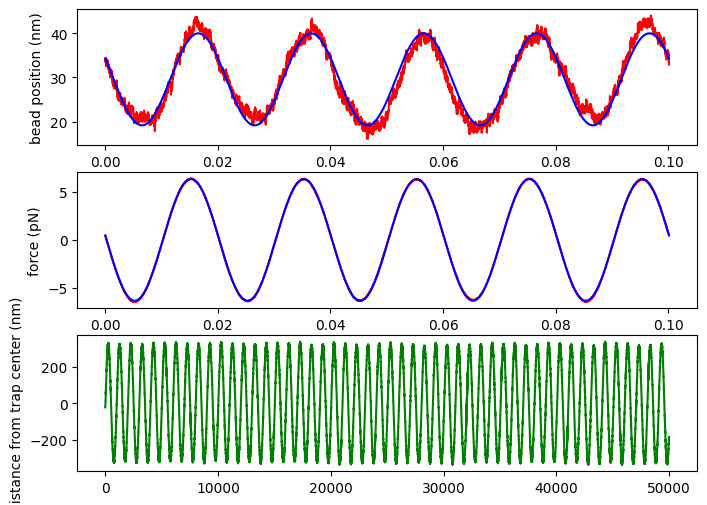

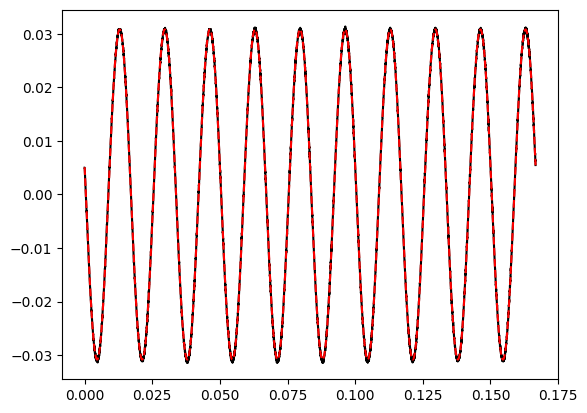

Original frequency:  60.0   FG frequency:  59.97689313085551  ratio =  0.9996148855142585


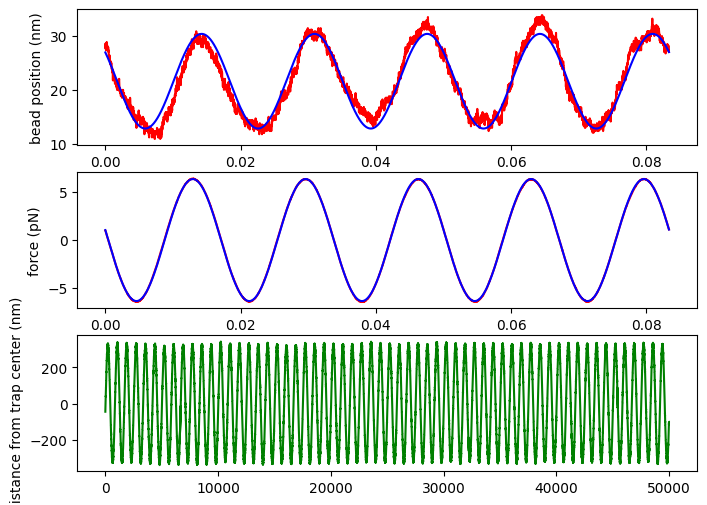

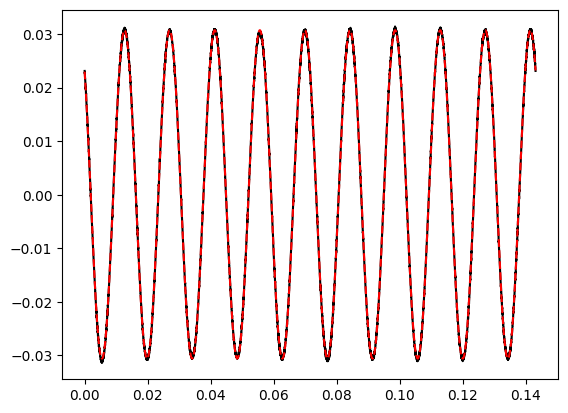

Original frequency:  70.0   FG frequency:  69.84887208748037  ratio =  0.9978410298211482


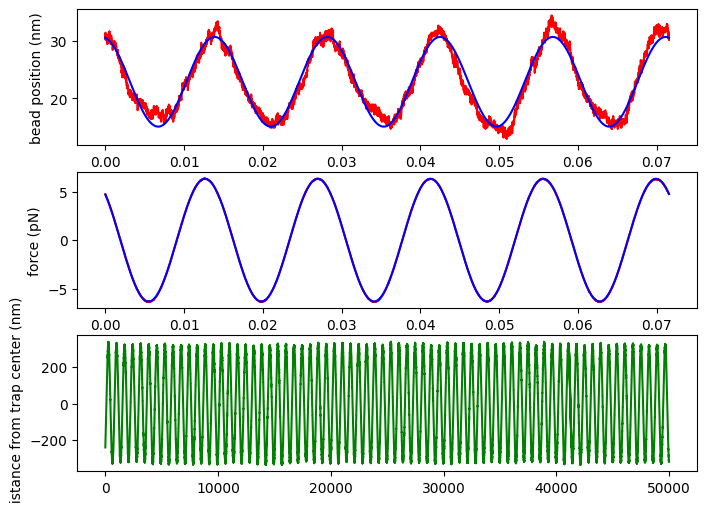

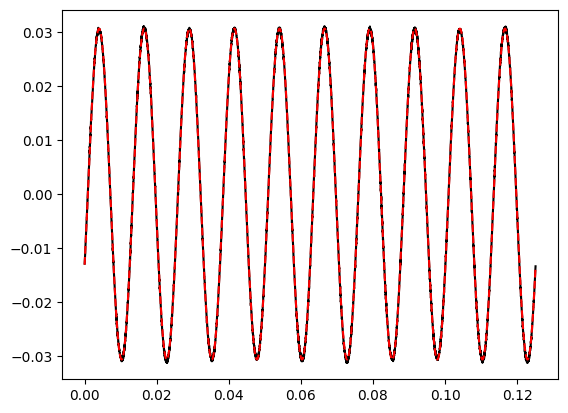

Original frequency:  80.0   FG frequency:  79.90689508850005  ratio =  0.9988361886062507


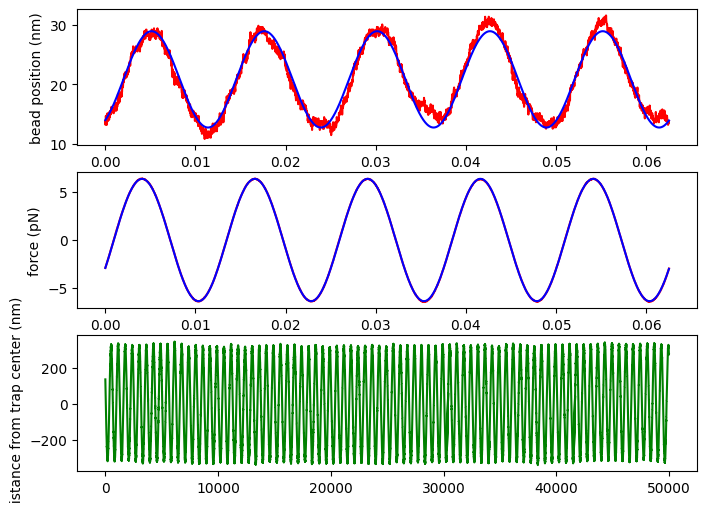

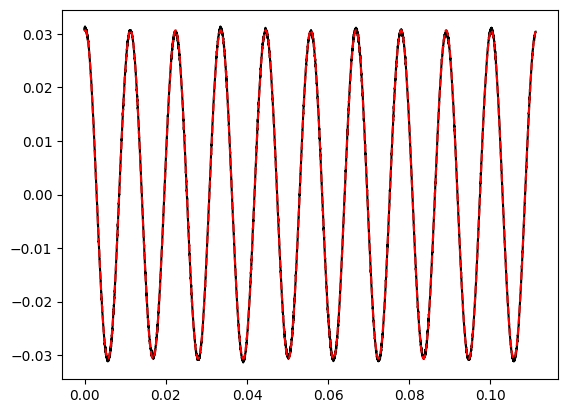

Original frequency:  90.0   FG frequency:  89.96521286098773  ratio =  0.9996134762331971


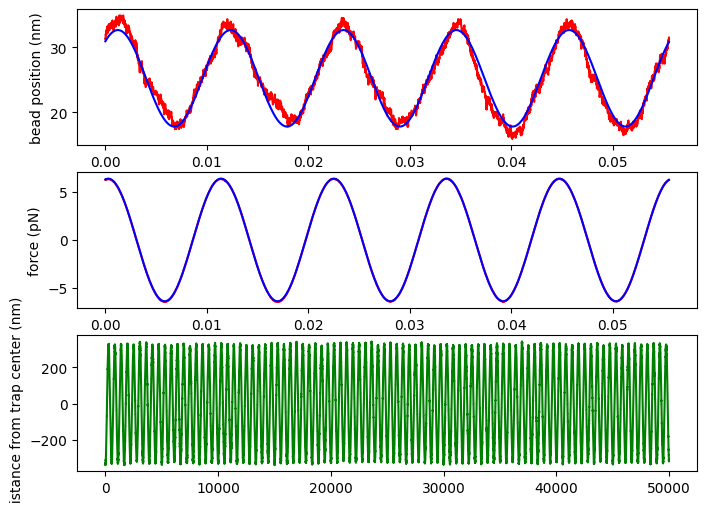

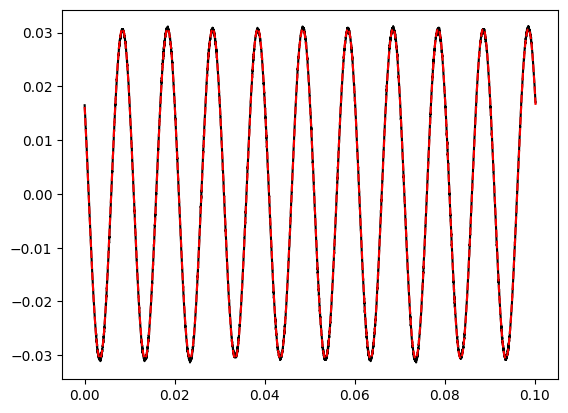

Original frequency:  100.0   FG frequency:  99.83715576463248  ratio =  0.9983715576463248


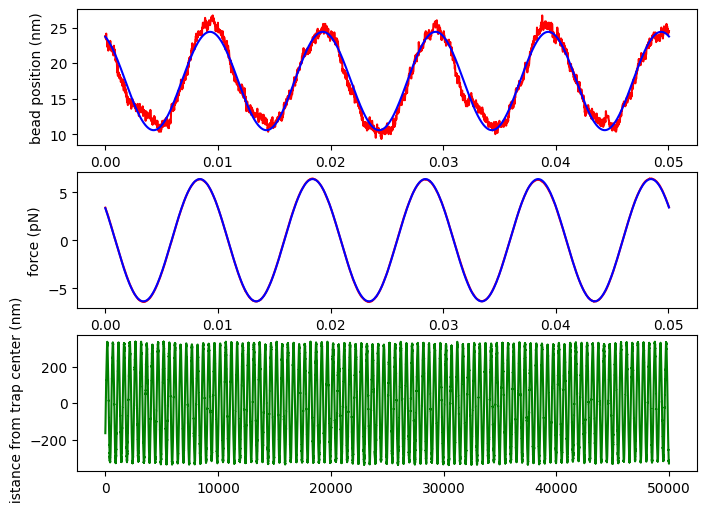

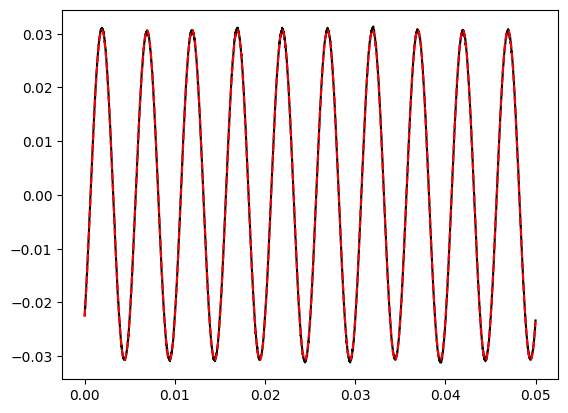

Original frequency:  200.0   FG frequency:  199.8604963549211  ratio =  0.9993024817746056


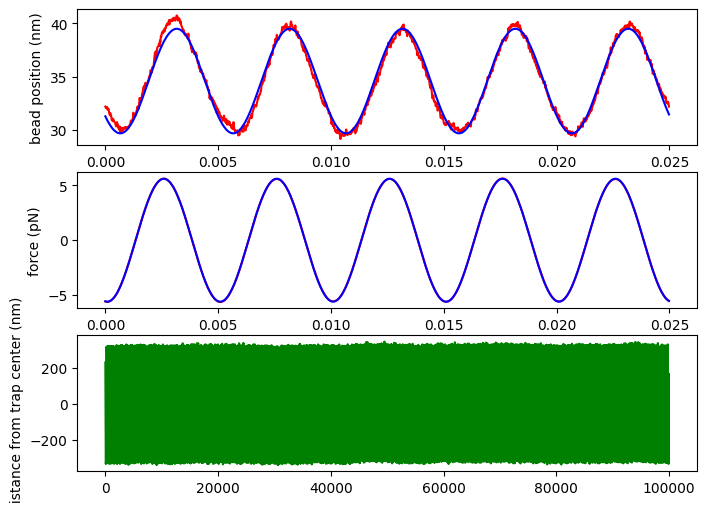

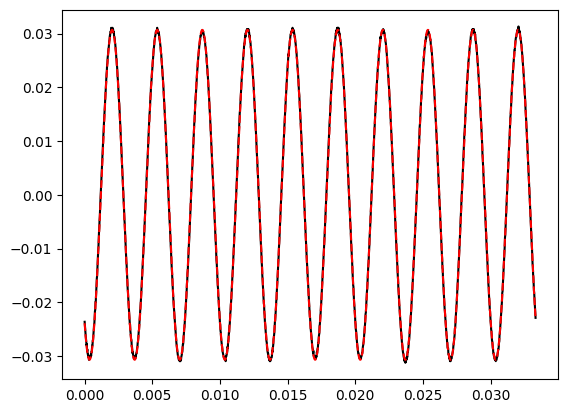

Original frequency:  300.0   FG frequency:  299.8839417450885  ratio =  0.999613139150295


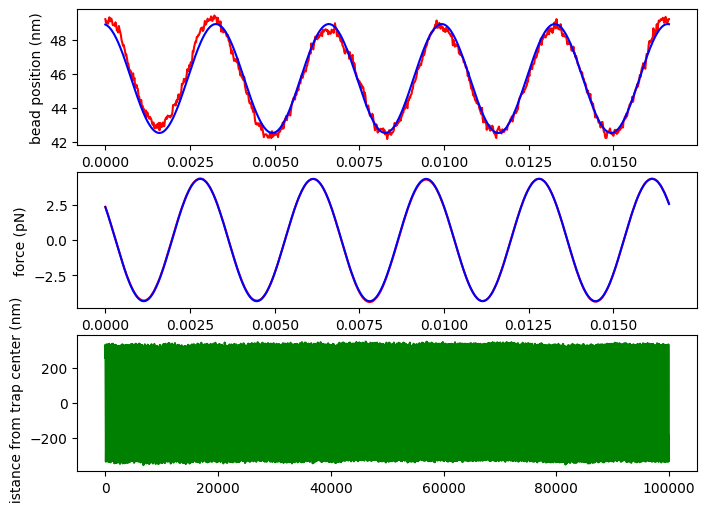

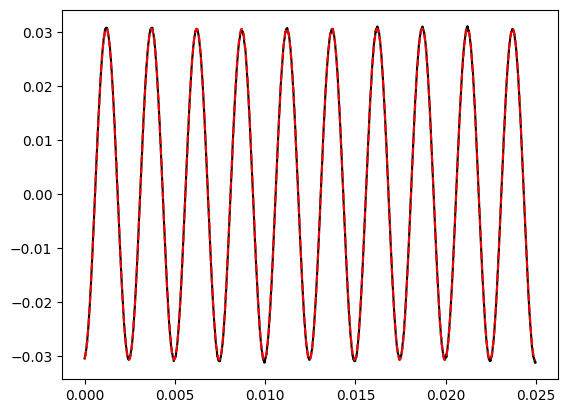

Original frequency:  400.0   FG frequency:  399.90725606322206  ratio =  0.9997681401580552


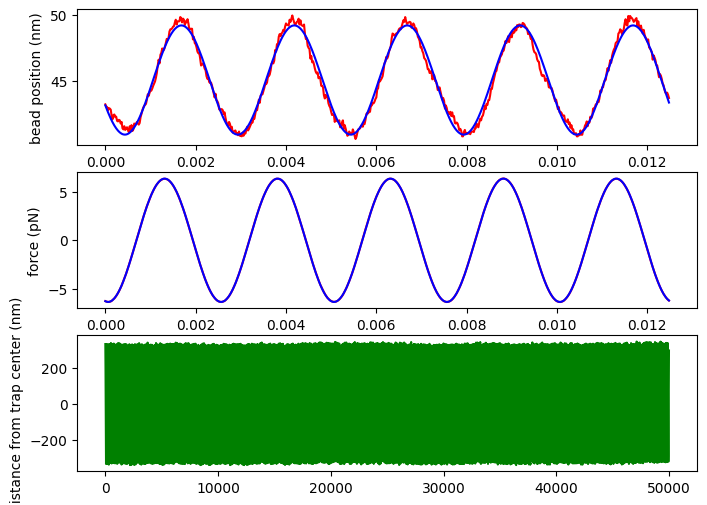

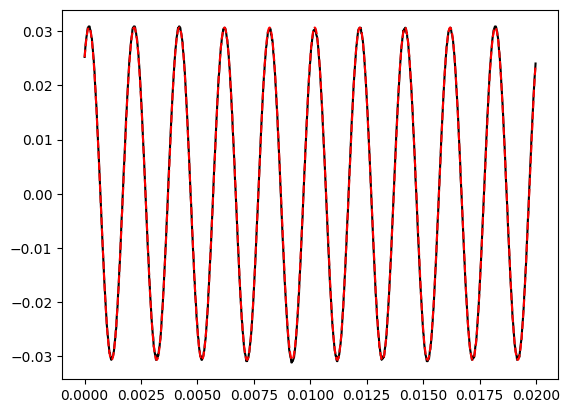

Original frequency:  500.0   FG frequency:  499.9306839875433  ratio =  0.9998613679750866


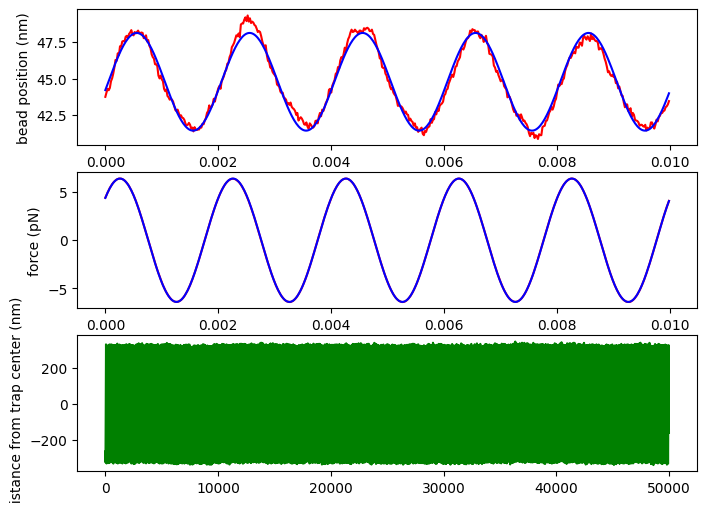

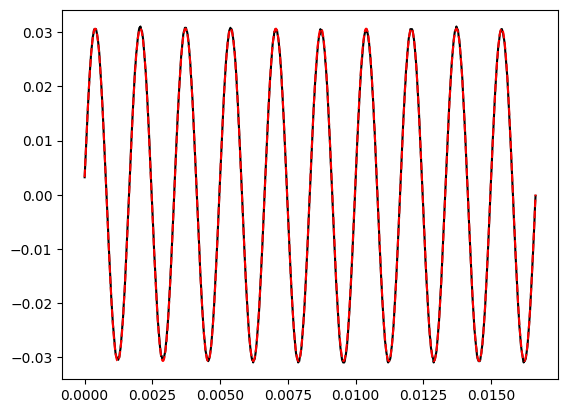

Original frequency:  600.0   FG frequency:  599.9540419470509  ratio =  0.9999234032450848


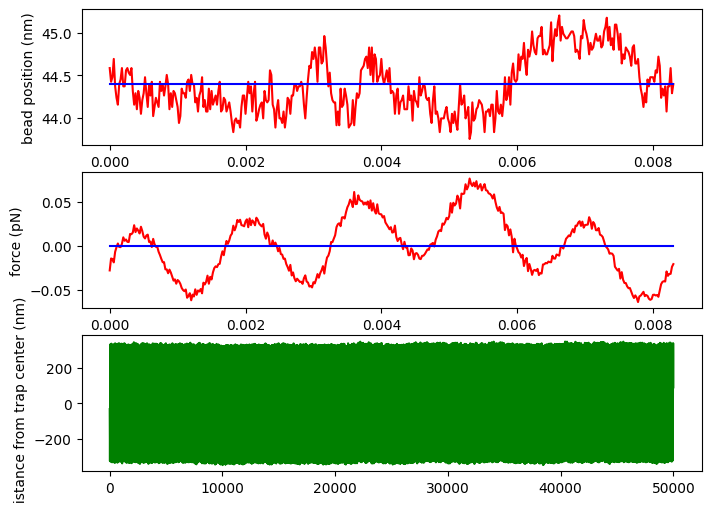

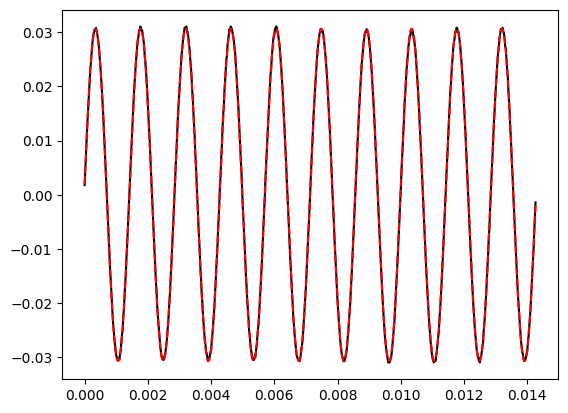

Original frequency:  700.0   FG frequency:  699.9774344161019  ratio =  0.9999677634515741


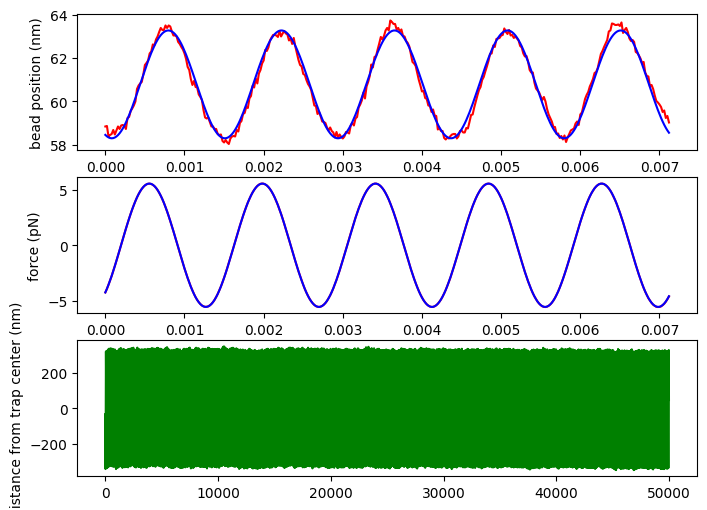

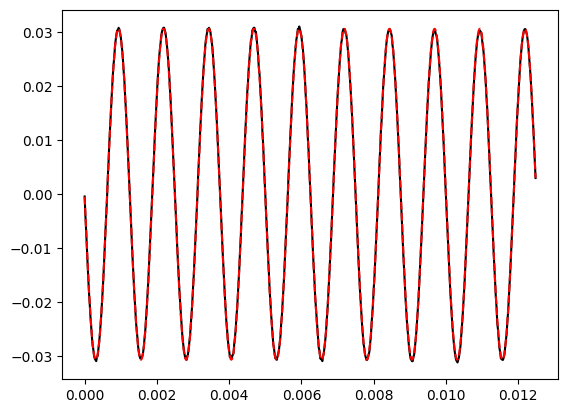

Original frequency:  800.0   FG frequency:  799.8145665797113  ratio =  0.9997682082246391


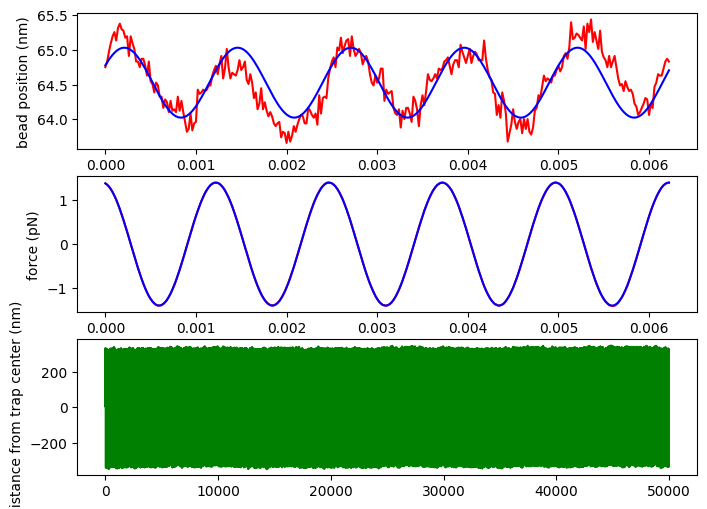

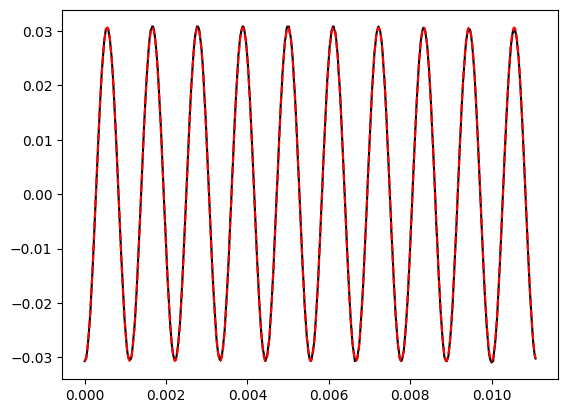

Original frequency:  900.0   FG frequency:  899.8378989246432  ratio =  0.9998198876940481


<ipython-input-12-3d99f5bf87df>:94: OptimizeWarning: Covariance of the parameters could not be estimated
  params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(y)*np.sqrt(2), phase, 0])


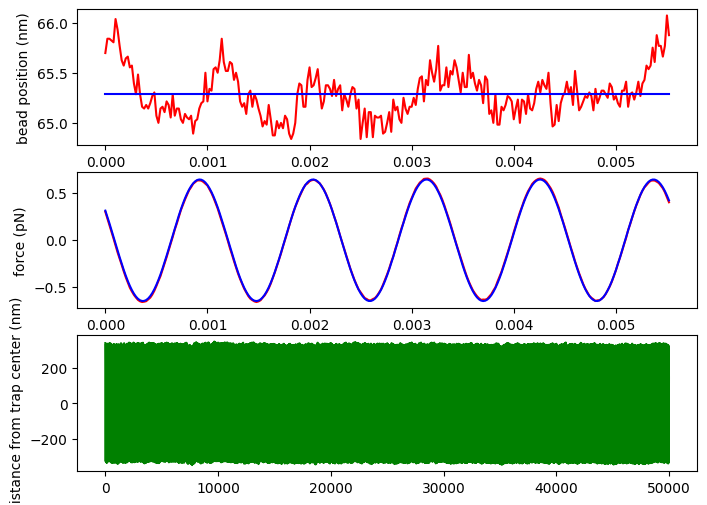

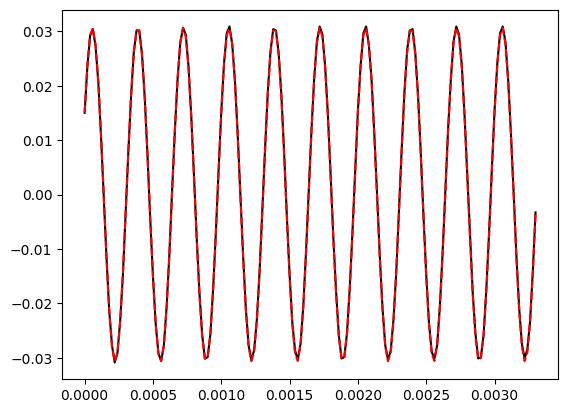

Original frequency:  3000.0   FG frequency:  2999.956505814346  ratio =  0.9999855019381154


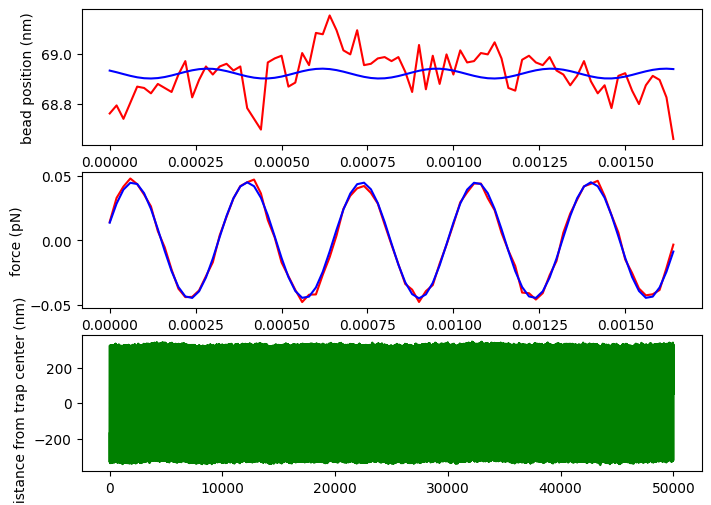

In [ ]:
# This code was updated during Feb 2025

from scipy import optimize
def sinefit(t, A, C, D, omega):
    return np.abs(A) * np.sin(omega*t - C)+D
def sinefit2(omegaoscil):
  def func(t,*p):
    return np.abs(p[0]) * np.sin(omegaoscil*t - p[1])+p[2]
  return func


pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/250212/'

plt.figure()
frequencies = np.array([])

for i in range(0, 133):
  y, x, sumsignal, fg= loaddataquiet('bead5/bead5_', i, i+1, 0)
  t = np.arange(0, len(yb)/fs, 1/fs)
  Y = fft(fg)
  N = len(Y)
  n = np.arange(N)
  T = N/fs
  freq = n/T
  index = (freq>0.1)*(freq<20000)
  freqsec = freq[index]
  Ysec = np.abs(Y[index])
  frequencies = np.append(frequencies, freqsec[Ysec == np.max(Ysec)])

changesindex = (np.diff(frequencies)>0.5)
filenumber = np.arange(1, 133, 1)
fn_change = filenumber[changesindex]
frequencies = np.append(1, frequencies[fn_change])

freqlist = np.array([])
Fnot = np.array([])
ynot = np.array([])
delta = np.array([])
for i in range(0, len(fn_change)-1):
  if i == 0:
    x, y, sumsignal, fg= loaddataquiet('bead5/bead5_', 0, fn_change[i]-1, 0)
  else:
    x, y, sumsignal, fg= loaddataquiet('bead5/bead5_', fn_change[i-1]+1, fn_change[i]-1, 0)

  if len(fg) > 0:
    times = np.arange(0, dt*len(y), dt)
    tdata = times
    OTdata = a*fg+b

    fgfit = fg-np.mean(fg)
    #plt.figure()
    #plt.plot(tdata, fg, 'k')
    params, params_covariance = optimize.curve_fit(sinefit, tdata, fgfit, p0=[np.std(fgfit)*np.sqrt(2), 0, 0, 2*np.pi*frequencies[i]])
    if np.abs(np.std(fgfit)*np.sqrt(2)/params[0])>2:
      params, params_covariance = optimize.curve_fit(sinefit, tdata, fgfit, p0=[np.std(fgfit)*np.sqrt(2), np.pi, 0, 2*np.pi*frequencies[i]])
    freqlist = np.append(freqlist, params[3]/(2*np.pi))
    # plt.figure()
    # plt.plot(tdata[0:int(2*np.pi*10*fs/params[3])], fgfit[0:int(2*np.pi*10*fs/params[3])], 'k')
    # plt.plot(tdata[0:int(2*np.pi*10*fs/params[3])], sinefit(tdata[0:int(2*np.pi*10*fs/params[3])], *params), 'r--')
    # plt.show()

    phase = params[1]
    print('Original frequency: ', frequencies[i], '  FG frequency: ', params[3]/(2*np.pi), ' ratio = ', params[3]/(2*np.pi)/frequencies[i])#
    #plt.plot(tdata, sinefit(tdata, *params), 'r--')
    #plt.show()

    y = y*1e9
    Fcurve = -(ky / 1e-12 * 1e-9) * ((y-np.mean(y)) - (OTdata-np.mean(OTdata)))  # in pN
    Noscil = 5
    freqoscil = params[3]/(2*np.pi)
    # FIT the y data

    aveydata = np.zeros(int((Noscil/freqoscil)/dt))
    aveFdata = np.zeros(int((Noscil/freqoscil)/dt))
    count = 0
    for j in range(0, len(y), int((Noscil/freqoscil)/dt)):
      if len(y[j:j+int((Noscil/freqoscil)/dt)]) == len(aveydata):
        count = count+1
        aveydata = aveydata + y[j:j+int((Noscil/freqoscil)/dt)]
        aveFdata = aveFdata + Fcurve[j:j+int((Noscil/freqoscil)/dt)]
        times = dt*np.arange(0, len(y[j:j+int((Noscil/freqoscil)/dt)]), 1)
    aveydata = aveydata/count
    aveFdata = aveFdata/count
    plt.figure(figsize = (8, 6))
    plt.subplot(3, 1, 1)
    plt.plot(times, aveydata, 'r')
    plt.ylabel('bead position (nm)')
    plt.subplot(3, 1, 2)
    plt.plot(times, aveFdata, 'r')
    plt.ylabel('force (pN)')
    plt.xlabel('time (s)')


    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(y)*np.sqrt(2), phase, 0])
    if np.std(y)*np.sqrt(2)/params[0]>2:
      params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(y)*np.sqrt(2), np.pi, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.subplot(3, 1, 1)
    plt.plot(times, sinefit(times, *params), 'b-')
    yphase = params[1]
    ynot = np.append(ynot, params[0]*1e-9)


    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveFdata, p0=[np.std(Fcurve)*np.sqrt(2), 0, 0])
    if np.std(Fcurve)*np.sqrt(2)/params[0]>2 or np.std(Fcurve)*np.sqrt(2)/params[0]<0.5:
      params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveFdata, p0=[np.std(Fcurve)*np.sqrt(2), np.pi, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.subplot(3, 1, 2)
    plt.plot(times, sinefit(times, *params), 'b-')
    plt.subplot(3, 1, 3)
    plt.plot( ((y-np.mean(y)) - (OTdata-np.mean(OTdata))), 'g')
    plt.ylabel('distance from trap center (nm)')




    Fnot = np.append(Fnot, params[0]*1e-12)
    deltatemp = yphase-params[1]
    if deltatemp<0:
      deltatemp = deltatemp+2*np.pi
    delta = np.append(delta, deltatemp)

    plt.show()

Gprime_5a = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.cos(delta)
Gprimeprime_5a = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.sin(delta)




# Generate interesting plots below!

(0.9, 5000)

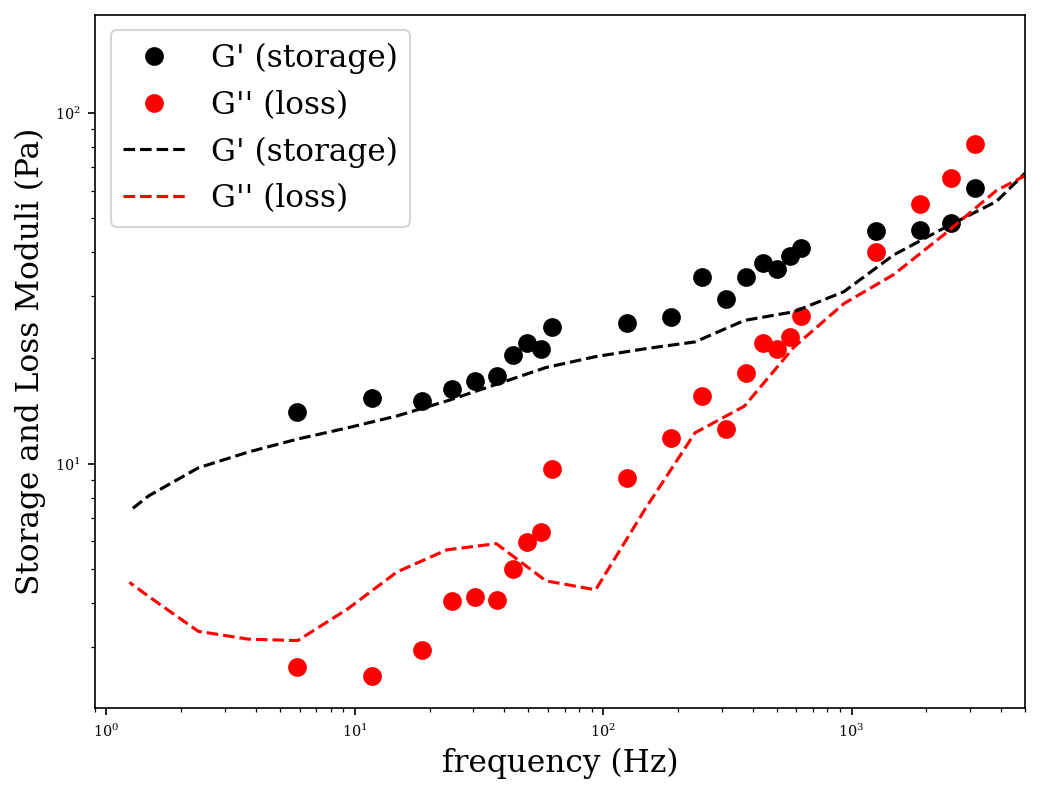

In [ ]:
index = (freqlist<590)  # this is where we indicate which active data were successfully fit
plt.figure(figsize = (8, 6))
plt.loglog(2*np.pi*freqlist[index], Gprime_5a[index], 'ko', label = 'G\' (storage)', markersize = 8)
plt.loglog(2*np.pi*freqlist[index], Gprimeprime_5a[index], 'ro', label = 'G\'\' (loss)', markersize = 8)

plt.plot(omegalist_5p[1:], Gprime_5p, 'k--', label = 'G\' (storage)', markersize = 8)
plt.plot(omegalist_5p[1:], Gprimeprime_5p, 'r--', label = 'G\'\' (loss)', markersize = 8)


plt.xlabel('frequency (Hz)', fontsize = 15)
plt.ylabel('Storage and Loss Moduli (Pa)', fontsize = 15)
plt.legend(fontsize = 15)
plt.xlim(0.9, 5000)

(1.0, 100.0)

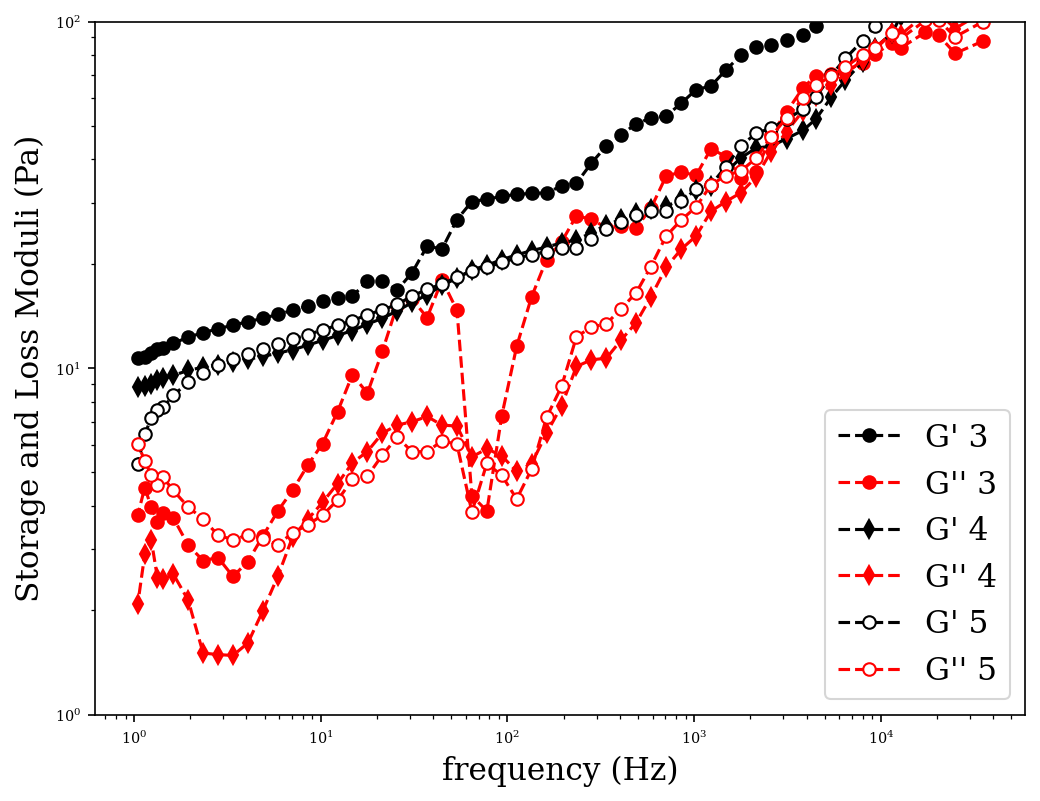

In [ ]:
index = (freqlist<590)  # this is where we indicate which active data were successfully fit
plt.figure(figsize = (8, 6))

plt.loglog(omegalist_5p[1:], Gprime_3p, 'k--o', label = 'G\' 3', markersize = 6)
plt.loglog(omegalist_5p[1:], Gprimeprime_3p, 'r--o', label = 'G\'\' 3', markersize = 6)

plt.loglog(omegalist_5p[1:], Gprime_4p, 'k--d', label = 'G\' 4', markersize = 6)
plt.loglog(omegalist_5p[1:], Gprimeprime_4p, 'r--d', label = 'G\'\' 4', markersize = 6)

plt.loglog(omegalist_5p[1:], Gprime_5p, 'k--o', label = 'G\' 5', markersize = 6, markerfacecolor = 'white')
plt.loglog(omegalist_5p[1:], Gprimeprime_5p, 'r--o', label = 'G\'\' 5', markersize = 6, markerfacecolor = 'white')



plt.xlabel('frequency (Hz)', fontsize = 15)
plt.ylabel('Storage and Loss Moduli (Pa)', fontsize = 15)
plt.legend(fontsize = 15)
plt.ylim(1e0, 1e2)